# Conventional Gap Trading Workflow


## Imports


In [120]:
from __future__ import annotations
import errno
import logging
import os
import re
import sys
import tempfile
from contextlib import contextmanager
from datetime import datetime, timezone, timedelta
from functools import partial
from math import pi
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import polars as pl
import psycopg2
import yaml
from deltalake import DeltaTable, write_deltalake
from feast import Entity, FeatureService, FeatureView, Field, FeatureStore
from feast.infra.offline_stores.contrib.postgres_offline_store.postgres_source import PostgreSQLSource
from feast.types import Float64, Int64
from psycopg2.extras import execute_values
from matplotlib.patches import Rectangle
from datetime import datetime, timezone
import polars_ta.talib as pl_ta
from datetime import timedelta
from feast import Entity, FeatureService, FeatureView, Field
from feast.infra.offline_stores.contrib.postgres_offline_store.postgres_source import (
    PostgreSQLSource,
)
from feast import FeatureStore


## Configuration


In [121]:
# config_resolvers.py
def configured_list(mapping: dict[str, Any], key: str) -> list[str]:
    return list(mapping.get(key, []))


In [122]:
# config_resolvers.py
def resolve_column_config(columns: dict[str, Any]) -> dict[str, list[str]]:
    entity_columns = configured_list(columns, "entity")
    price_columns = configured_list(columns, "price")
    analytics_calendar_columns = configured_list(columns, "analytics_calendar")
    target_columns = configured_list(columns, "target")
    tier_1_feature_columns = configured_list(columns, "tier_1_features")
    model_time_feature_columns = configured_list(columns, "model_time_features")
    indicator_columns = configured_list(columns, "indicator")
    condition_columns = configured_list(columns, "condition")
    strategy_label_columns = configured_list(columns, "strategy_label")
    output_audit_columns = configured_list(columns, "output_audit")
    close_model_time_feature_columns = configured_list(
        columns,
        "close_model_time_features",
    )
    tier_2_feature_columns = list(
        columns.get(
            "tier_2_features",
            [*tier_1_feature_columns, *model_time_feature_columns],
        )
    )
    tier_3_feature_columns = list(
        columns.get(
            "tier_3_features",
            tier_2_feature_columns,
        )
    )
    indicator_feature_columns = list(
        columns.get(
            "indicator_features",
            [
                *entity_columns,
                *output_audit_columns,
                *price_columns,
                *analytics_calendar_columns,
                *target_columns,
                *tier_1_feature_columns,
                *model_time_feature_columns,
                *indicator_columns,
            ],
        )
    )
    conventional_gap_trading_columns = list(
        columns.get(
            "conventional_gap_trading",
            [
                *indicator_feature_columns,
                *condition_columns,
                *strategy_label_columns,
            ],
        )
    )
    close_model_dataset_columns = list(
        columns.get(
            "close_model_dataset",
            [
                "unique_id",
                "ds",
                "y",
                *close_model_time_feature_columns,
                *output_audit_columns,
            ],
        )
    )
    return {
        "entity": entity_columns,
        "price": price_columns,
        "analytics_calendar": analytics_calendar_columns,
        "target": target_columns,
        "tier_1_features": tier_1_feature_columns,
        "tier_2_features": tier_2_feature_columns,
        "tier_3_features": tier_3_feature_columns,
        "fourier_time_encoding": configured_list(columns, "fourier_time_encoding"),
        "model_time_features": model_time_feature_columns,
        "indicator": indicator_columns,
        "condition": condition_columns,
        "strategy_required_conditions": configured_list(
            columns,
            "strategy_required_conditions",
        ),
        "strategy_label": strategy_label_columns,
        "output_audit": output_audit_columns,
        "indicator_features": indicator_feature_columns,
        "conventional_gap_trading": conventional_gap_trading_columns,
        "close_model_time_features": close_model_time_feature_columns,
        "close_model_dataset": close_model_dataset_columns,
        "model_ready": list(
            columns.get(
                "model_ready",
                [
                    *tier_1_feature_columns,
                    *model_time_feature_columns,
                    *indicator_columns,
                ],
            )
        ),
    }


## Feature Engineering Utilities


In [123]:
# features/feature_engineering_utils.py
def _harmonics(time_encoding_config: dict[str, Any], key: str) -> tuple[int, ...]:
    return tuple(time_encoding_config.get(key, [1, 2]))


In [124]:
# features/feature_engineering_utils.py
def _period(time_encoding_config: dict[str, Any], column: str) -> float:
    return float(time_encoding_config.get("periods", {}).get(column))


In [125]:
# features/feature_engineering_utils.py
def prepare_feature_source(
    df: pl.DataFrame,
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    return (
        df.select(
            pl.col("symbol").cast(pl.Utf8).str.to_uppercase(),
            pl.col("date").cast(pl.Datetime("us"), strict=False),
            pl.col("open").cast(pl.Float64, strict=False),
            pl.col("high").cast(pl.Float64, strict=False),
            pl.col("low").cast(pl.Float64, strict=False),
            pl.col("close").cast(pl.Float64, strict=False),
            pl.col("volume").cast(pl.Float64, strict=False),
        )
        .with_columns(
            pl.col("date").dt.month().cast(pl.Int8).alias("month"),
            pl.col("date").dt.day().cast(pl.Int8).alias("day"),
            pl.col("date").dt.ordinal_day().cast(pl.Int16).alias("day_of_year"),
        )
        .with_columns(
            [
                *fourier_terms(
                    "month",
                    period=_period(time_encoding_config, "month"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
                *fourier_terms(
                    "day",
                    period=_period(time_encoding_config, "day"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
                *fourier_terms(
                    "day_of_year",
                    period=_period(time_encoding_config, "day_of_year"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
            ]
        )
        .drop(["month", "day", "day_of_year"])
    )


In [126]:
# features/feature_engineering_utils.py
def map_by_symbol(df: pl.DataFrame, function) -> pl.DataFrame:
    return df.group_by("symbol", maintain_order=True).map_groups(function)


In [127]:
# features/feature_engineering_utils.py
def fourier_terms(
    column: str,
    period: float,
    harmonics: tuple[int, ...],
):
    expressions = []
    for harmonic in harmonics:
        angle = 2.0 * pi * harmonic * pl.col(column).cast(pl.Float64) / period
        expressions.extend(
            [
                angle.sin().alias(f"{column}_sin_{harmonic}"),
                angle.cos().alias(f"{column}_cos_{harmonic}"),
            ]
        )
    return expressions


In [128]:
# features/feature_engineering_utils.py
def add_calendar_gap_days(df_symbol: pl.DataFrame) -> pl.DataFrame:
    date_gaps = (
        df_symbol.select(pl.col("date").dt.date().alias("_event_date"))
        .unique()
        .sort("_event_date")
    )

    date_index = pl.col("_event_date").cast(pl.Int32)
    gap_expr = date_index.diff().fill_null(1) - 1
    date_gaps = date_gaps.with_columns(
        pl.when(gap_expr > 0)
        .then(gap_expr)
        .otherwise(0)
        .cast(pl.Int32)
        .alias("calendar_gap_days")
    )

    return (
        df_symbol.with_columns(pl.col("date").dt.date().alias("_event_date"))
        .join(date_gaps, on="_event_date", how="left")
        .drop("_event_date")
    )


In [129]:
# features/feature_engineering_utils.py
def add_time_encoding_for_symbol(
    df_symbol: pl.DataFrame,
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    return (
        add_calendar_gap_days(df_symbol.sort("date"))
        .with_columns(
            pl.col("date").dt.month().cast(pl.Int8).alias("month"),
            pl.col("date").dt.day().cast(pl.Int8).alias("day"),
        )
        .with_columns(
            pl.col("date")
            .dt.ordinal_day()
            .cast(pl.Int16)
            .alias("day_of_year")
        )
        .with_columns(
            [
                *fourier_terms(
                    "month",
                    period=_period(time_encoding_config, "month"),
                    harmonics=_harmonics(time_encoding_config, "source_harmonics"),
                ),
                *fourier_terms(
                    "day",
                    period=_period(time_encoding_config, "day"),
                    harmonics=_harmonics(time_encoding_config, "source_harmonics"),
                ),
                *fourier_terms(
                    "day_of_year",
                    period=_period(time_encoding_config, "day_of_year"),
                    harmonics=_harmonics(time_encoding_config, "source_harmonics"),
                ),
            ]
        )
        .sort("date")
    )


In [130]:
# features/feature_engineering_utils.py
def add_model_training_tier_columns_for_symbol(
    df_symbol: pl.DataFrame,
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    return add_time_encoding_for_symbol(df_symbol, time_encoding_config).with_columns(
        pl.col("close").alias("target_close"),
        pl.col("open").shift(1).alias("prev_open"),
        pl.col("high").shift(1).alias("prev_high"),
        pl.col("low").shift(1).alias("prev_low"),
        pl.col("volume").shift(1).alias("prev_volume"),
    )


In [131]:
# features/feature_engineering_utils.py
def with_created_timestamp(df: pl.DataFrame) -> pl.DataFrame:
    created_timestamp = datetime.now(timezone.utc)
    return df.with_columns(pl.lit(created_timestamp).alias("created_timestamp"))


In [132]:
# features/feature_engineering_utils.py
def drop_rows_with_missing_model_features(
    df: pl.DataFrame,
    model_ready_columns: list[str],
) -> pl.DataFrame:
    return df.drop_nulls(model_ready_columns).filter(
        pl.all_horizontal(pl.col(model_ready_columns).is_finite())
    )


In [133]:
# features/feature_engineering_utils.py
def _add_close_model_time_encoding(
    df: pl.DataFrame,
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    return (
        df.with_columns(
            pl.col("ds").dt.month().cast(pl.Int8).alias("month"),
            pl.col("ds").dt.day().cast(pl.Int8).alias("day"),
            pl.col("ds").dt.ordinal_day().cast(pl.Int16).alias("day_of_year"),
        )
        .with_columns(
            [
                *fourier_terms(
                    "month",
                    period=_period(time_encoding_config, "month"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
                *fourier_terms(
                    "day",
                    period=_period(time_encoding_config, "day"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
                *fourier_terms(
                    "day_of_year",
                    period=_period(time_encoding_config, "day_of_year"),
                    harmonics=_harmonics(time_encoding_config, "close_model_harmonics"),
                ),
            ]
        )
        .drop(["month", "day", "day_of_year"])
    )


In [134]:
# features/feature_engineering_utils.py
def _fill_close_model_business_day_gaps(
    df: pl.DataFrame,
    close_model_freq: str,
) -> pl.DataFrame:
    if df.is_empty():
        return df

    interval = "1d" if close_model_freq.upper() == "B" else close_model_freq
    source = (
        df.with_row_index("_source_order")
        .sort(["unique_id", "ds", "_source_order"])
        .unique(subset=["unique_id", "ds"], keep="last", maintain_order=True)
        .drop("_source_order")
    )
    date_grid = (
        source.group_by("unique_id")
        .agg(
            pl.datetime_ranges(
                pl.col("ds").min(),
                pl.col("ds").max(),
                interval=interval,
            ).alias("ds")
        )
        .explode("ds")
    )
    if close_model_freq.upper() == "B":
        date_grid = date_grid.filter(pl.col("ds").dt.weekday() <= 5)

    return (
        date_grid.join(source, on=["unique_id", "ds"], how="left")
        .sort(["unique_id", "ds"])
        .with_columns(
            pl.col("y")
            .forward_fill()
            .backward_fill()
            .over("unique_id")
            .alias("y")
        )
        .select(["unique_id", "ds", "y"])
    )


In [135]:
# features/feature_engineering_utils.py
def to_stock_close_model_dataset(
    df: pl.DataFrame,
    output_columns: list[str],
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    model_dataset = (
        df.select(
            pl.col("symbol").cast(pl.Utf8).alias("unique_id"),
            pl.col("date")
            .cast(pl.Datetime("us"), strict=False)
            .dt.truncate("1d")
            .alias("ds"),
            pl.col("close").cast(pl.Float64, strict=False).alias("y"),
        )
        .drop_nulls(["unique_id", "ds", "y"])
        .unique(subset=["unique_id", "ds"], keep="last", maintain_order=True)
        .sort(["unique_id", "ds"])
    )
    return with_created_timestamp(
        _add_close_model_time_encoding(
            _fill_close_model_business_day_gaps(
                model_dataset,
                time_encoding_config.get("close_model_freq", "B"),
            ),
            time_encoding_config,
        )
    ).select(output_columns)


## Indicators


In [136]:
# features/indicators.py
def calculate_indicators_for_symbol(df_symbol: pl.DataFrame) -> pl.DataFrame:
    expressions = [
        pl_ta.RSI(pl.col("close"), timeperiod=14).alias("RSI"),
        pl_ta.SMA(pl.col("close"), timeperiod=20).alias("SMA_Short"),
        pl_ta.SMA(pl.col("close"), timeperiod=50).alias("SMA_Long"),
        pl_ta.SMA(pl.col("volume"), timeperiod=20).alias("Vol_SMA"),
        pl.col("high")
        .cast(pl.Float64)
        .shift(1)
        .rolling_max(window_size=20)
        .alias("Range_high"),
        pl.col("low")
        .cast(pl.Float64)
        .shift(1)
        .rolling_min(window_size=20)
        .alias("Range_low"),
        pl_ta.ADX(
            pl.col("high"),
            pl.col("low"),
            pl.col("close"),
            timeperiod=14,
        ).alias("ADX"),
    ]

    return df_symbol.with_columns(expressions)


## Conditions


In [137]:
# features/conditions.py
def calculate_conditions_for_symbol(
    df_symbol: pl.DataFrame,
    condition_columns: list[str],
) -> pl.DataFrame:
    expressions = [
        (pl.col("low") > pl.col("high").shift(1)).alias("gap_up"),
        (pl.col("high") < pl.col("low").shift(1)).alias("gap_down"),
        (pl.col("open") > pl.col("close").shift(1)).alias(
            "exhaustion_gap_up"
        ),
        (pl.col("open") < pl.col("close").shift(1)).alias(
            "exhaustion_gap_down"
        ),
        (pl.col("volume") > (1.5 * pl.col("Vol_SMA"))).alias("high_vol"),
        (pl.col("volume") > (2.0 * pl.col("Vol_SMA"))).alias("extreme_vol"),
        (pl.col("low") > pl.col("Range_high")).alias("breakout_up"),
        (pl.col("high") < pl.col("Range_low")).alias("breakout_down"),
        (pl.col("ADX") < 25).alias("consolidation"),
        (pl.col("SMA_Short") > pl.col("SMA_Long")).alias("uptrend"),
        (pl.col("SMA_Short") < pl.col("SMA_Long")).alias("downtrend"),
        (pl.col("RSI") > 70).alias("overbought"),
        (pl.col("RSI") < 30).alias("oversold"),
    ]

    return df_symbol.with_columns(expressions).with_columns(
        pl.col(condition_columns).fill_null(False)
    )


## Strategy


In [138]:
# features/strategy.py
def classify_strategy_for_symbol(
    df_symbol: pl.DataFrame,
    required_condition_columns: list[str],
) -> pl.DataFrame:
    if not all(column in df_symbol.columns for column in required_condition_columns):
        return df_symbol

    return df_symbol.with_columns(
        pl.when(
            pl.col("gap_up")
            & pl.col("breakout_up")
            & pl.col("high_vol")
            & pl.col("consolidation").shift(1).fill_null(False)
        )
        .then(pl.lit("Breakaway Up"))
        .when(
            pl.col("gap_down")
            & pl.col("breakout_down")
            & pl.col("high_vol")
            & pl.col("consolidation").shift(1).fill_null(False)
        )
        .then(pl.lit("Breakaway Down"))
        .when(
            pl.col("exhaustion_gap_up")
            & pl.col("uptrend")
            & pl.col("overbought")
            & pl.col("extreme_vol")
            & ~pl.col("consolidation")
        )
        .then(pl.lit("Exhaustion Up"))
        .when(
            pl.col("exhaustion_gap_down")
            & pl.col("downtrend")
            & pl.col("oversold")
            & pl.col("extreme_vol")
            & ~pl.col("consolidation")
        )
        .then(pl.lit("Exhaustion Down"))
        .when(
            pl.col("gap_up")
            & pl.col("uptrend")
            & ~pl.col("breakout_up")
            & ~pl.col("overbought")
            & ~pl.col("consolidation")
        )
        .then(pl.lit("Runaway Up"))
        .when(
            pl.col("gap_down")
            & pl.col("downtrend")
            & ~pl.col("breakout_down")
            & ~pl.col("oversold")
            & ~pl.col("consolidation")
        )
        .then(pl.lit("Runaway Down"))
        .when(pl.col("gap_up") & ~pl.col("breakout_up") & ~pl.col("high_vol"))
        .then(pl.lit("Common Up"))
        .when(pl.col("gap_down") & ~pl.col("breakout_down") & ~pl.col("high_vol"))
        .then(pl.lit("Common Down"))
        .otherwise(pl.lit("None"))
        .alias("Gap_Type")
    )


## Feature Sets


In [139]:
# features/feature_sets.py; notebook-safe path resolver
def _kedro_project_dir() -> Path:
    env_path = os.getenv("KEDRO_PROJECT_DIR")
    if env_path:
        return Path(env_path).expanduser().resolve()

    kedro_project = globals().get("KEDRO_PROJECT")
    if kedro_project:
        return Path(kedro_project).expanduser().resolve()

    workspace_root = globals().get("WORKSPACE_PROJECT_ROOT")
    candidates = [
        Path("/opt/kedro_project"),
        Path(workspace_root) / "kedro_project" if workspace_root else None,
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "kedro_project",
        Path.cwd().parent / "kedro_project",
    ]
    for candidate in candidates:
        if candidate is None:
            continue
        candidate = Path(candidate).expanduser().resolve()
        if (candidate / "conf" / "base" / "parameters_data_preprocessing.yml").exists():
            return candidate
    return Path.cwd().resolve()


In [140]:
# features/feature_sets.py
def _load_data_preprocessing_columns() -> dict[str, list[str]]:
    parameters_path = (
        _kedro_project_dir() / "conf" / "base" / "parameters_data_preprocessing.yml"
    )
    parameters = yaml.safe_load(parameters_path.read_text()) or {}
    data_preprocessing = parameters.get("stock_close_data_preprocessing", {})
    return resolve_column_config(data_preprocessing.get("columns", {}))


In [141]:
# features/feature_sets.py
def _column_config() -> dict[str, list[str]]:
    return _load_data_preprocessing_columns()


## Feature Engineering Orchestration


In [142]:
# feature_engineering.py
def delta_storage_options() -> dict[str, str]:
    endpoint = os.getenv("DELTA_LAKE_S3_ENDPOINT_URL", "http://host.docker.internal:9000")
    return {
        "AWS_ACCESS_KEY_ID": os.getenv("DELTA_LAKE_S3_ACCESS_KEY", "admin"),
        "AWS_SECRET_ACCESS_KEY": os.getenv("DELTA_LAKE_S3_SECRET_KEY", "admin1234"),
        "AWS_REGION": os.getenv("AWS_REGION", "us-east-1"),
        "AWS_ENDPOINT_URL": endpoint,
        "AWS_ALLOW_HTTP": os.getenv("AWS_ALLOW_HTTP", "true"),
        "AWS_S3_ALLOW_UNSAFE_RENAME": "true",
        "AWS_S3_FORCE_PATH_STYLE": "true",
    }


In [143]:
# feature_engineering.py
def silver_stock_prices_path(bucket: str) -> str:
    return f"s3://{bucket}/silver/stock_prices"


In [144]:
# feature_engineering.py
def stock_price_indicator_features_path(bucket: str) -> str:
    return f"s3://{bucket}/feature_engineering/stock_price_indicators"


In [145]:
# feature_engineering.py
def read_delta_table(path: str) -> pl.DataFrame:
    table = DeltaTable(path, storage_options=delta_storage_options())
    return pl.from_arrow(table.to_pyarrow_table())


In [146]:
# feature_engineering.py
def write_delta_table(path: str, df: pl.DataFrame, mode: str = "overwrite") -> None:
    schema_mode = "overwrite" if mode == "overwrite" else None
    write_deltalake(
        path,
        df.to_arrow(),
        mode=mode,
        schema_mode=schema_mode,
        storage_options=delta_storage_options(),
    )


In [147]:
# feature_engineering.py
def read_silver_stock_prices(bucket: str) -> pl.DataFrame:
    return read_delta_table(silver_stock_prices_path(bucket))


In [148]:
# feature_engineering.py
def build_stock_close_model_dataset(
    silver_stock_prices: pl.DataFrame,
    columns_config: dict[str, list[str]],
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    return to_stock_close_model_dataset(
        silver_stock_prices,
        columns_config["close_model_dataset"],
        time_encoding_config,
    )


In [149]:
# feature_engineering.py
def build_stock_price_indicator_features(
    silver_stock_prices: pl.DataFrame,
    columns_config: dict[str, list[str]],
    time_encoding_config: dict[str, Any],
) -> pl.DataFrame:
    feature_source = prepare_feature_source(silver_stock_prices, time_encoding_config)
    feature_enriched_prices = map_by_symbol(
        feature_source.drop_nulls(["symbol", "date"]).sort(["symbol", "date"]),
        partial(
            add_model_training_tier_columns_for_symbol,
            time_encoding_config=time_encoding_config,
        ),
    )
    indicators = map_by_symbol(
        feature_enriched_prices,
        calculate_indicators_for_symbol,
    )
    return with_created_timestamp(
        drop_rows_with_missing_model_features(indicators, columns_config["model_ready"])
    ).select(columns_config["indicator_features"])


In [150]:
# feature_engineering.py
def build_conventional_gap_trading_features(
    stock_price_indicator_features: pl.DataFrame,
    columns_config: dict[str, list[str]],
) -> pl.DataFrame:
    conditions = map_by_symbol(
        stock_price_indicator_features,
        partial(
            calculate_conditions_for_symbol,
            condition_columns=columns_config["condition"],
        ),
    )
    strategy_features = map_by_symbol(
        conditions,
        partial(
            classify_strategy_for_symbol,
            required_condition_columns=columns_config["strategy_required_conditions"],
        ),
    )
    return strategy_features.select(columns_config["conventional_gap_trading"])


## Feast And Timescale Serving


In [151]:
# serving/feast_store.py
def _ensure_feature_repo_on_path() -> None:
    (FEATURE_REPO_DIR / "data").mkdir(parents=True, exist_ok=True)
    feature_repo_parent = str(FEATURE_REPO_DIR.parent)
    if feature_repo_parent not in sys.path:
        sys.path.insert(0, feature_repo_parent)


In [152]:
# serving/feast_store.py
def _timescale_connection_kwargs() -> dict[str, str | int]:
    return {
        "host": os.getenv("TIMESCALE_HOST", "host.docker.internal"),
        "port": int(os.getenv("TIMESCALE_PORT", "5432")),
        "dbname": os.getenv("TIMESCALE_DB", "dataops"),
        "user": os.getenv("TIMESCALE_USER", "dataops"),
        "password": os.getenv("TIMESCALE_PASSWORD", "dataops"),
    }


In [153]:
# serving/feast_store.py
def _schema_name(table_name: str) -> str:
    return table_name.split(".", maxsplit=1)[0]


In [154]:
# serving/feast_store.py
def _create_timescale_feature_table(cursor) -> None:
    cursor.execute(f"CREATE SCHEMA IF NOT EXISTS {_schema_name(TIMESCALE_TABLE)};")
    cursor.execute(
        f"""
        CREATE TABLE IF NOT EXISTS {TIMESCALE_TABLE} (
            symbol TEXT NOT NULL,
            "date" TIMESTAMPTZ NOT NULL,
            created_timestamp TIMESTAMPTZ NOT NULL,
            prev_open DOUBLE PRECISION,
            prev_high DOUBLE PRECISION,
            prev_low DOUBLE PRECISION,
            prev_volume DOUBLE PRECISION,
            calendar_gap_days INTEGER,
            month_sin_1 DOUBLE PRECISION,
            month_cos_1 DOUBLE PRECISION,
            month_sin_2 DOUBLE PRECISION,
            month_cos_2 DOUBLE PRECISION,
            day_sin_1 DOUBLE PRECISION,
            day_cos_1 DOUBLE PRECISION,
            day_sin_2 DOUBLE PRECISION,
            day_cos_2 DOUBLE PRECISION,
            day_of_year_sin_1 DOUBLE PRECISION,
            day_of_year_cos_1 DOUBLE PRECISION,
            day_of_year_sin_2 DOUBLE PRECISION,
            day_of_year_cos_2 DOUBLE PRECISION,
            PRIMARY KEY (symbol, "date")
        );
        """
    )
    cursor.execute(
        f"""
        ALTER TABLE {TIMESCALE_TABLE}
            ADD COLUMN IF NOT EXISTS prev_open DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS prev_high DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS prev_low DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS prev_volume DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS calendar_gap_days INTEGER,
            ADD COLUMN IF NOT EXISTS month_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS month_cos_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS month_sin_2 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS month_cos_2 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_cos_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_sin_2 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_cos_2 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_cos_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_sin_2 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_cos_2 DOUBLE PRECISION;
        """
    )
    cursor.execute("CREATE EXTENSION IF NOT EXISTS timescaledb;")
    cursor.execute(
        """
        SELECT create_hypertable(
            %s,
            'date',
            if_not_exists => TRUE
        );
        """,
        (TIMESCALE_TABLE,),
    )


In [155]:
# serving/feast_store.py
def _create_timescale_close_model_dataset_table(cursor) -> None:
    cursor.execute(
        f"CREATE SCHEMA IF NOT EXISTS {_schema_name(TIMESCALE_CLOSE_MODEL_DATASET_TABLE)};"
    )
    cursor.execute(
        f"""
        CREATE TABLE IF NOT EXISTS {TIMESCALE_CLOSE_MODEL_DATASET_TABLE} (
            unique_id TEXT NOT NULL,
            ds TIMESTAMPTZ NOT NULL,
            y DOUBLE PRECISION NOT NULL,
            month_sin_1 DOUBLE PRECISION,
            month_cos_1 DOUBLE PRECISION,
            day_sin_1 DOUBLE PRECISION,
            day_cos_1 DOUBLE PRECISION,
            day_of_year_sin_1 DOUBLE PRECISION,
            day_of_year_cos_1 DOUBLE PRECISION,
            created_timestamp TIMESTAMPTZ NOT NULL,
            PRIMARY KEY (unique_id, ds)
        );
        """
    )
    cursor.execute(
        f"""
        ALTER TABLE {TIMESCALE_CLOSE_MODEL_DATASET_TABLE}
            ADD COLUMN IF NOT EXISTS month_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS month_cos_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_cos_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_sin_1 DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS day_of_year_cos_1 DOUBLE PRECISION;
        """
    )
    cursor.execute("CREATE EXTENSION IF NOT EXISTS timescaledb;")
    cursor.execute(
        """
        SELECT create_hypertable(
            %s,
            'ds',
            if_not_exists => TRUE
        );
        """,
        (TIMESCALE_CLOSE_MODEL_DATASET_TABLE,),
    )


In [156]:
# serving/feast_store.py
def _postgres_type_for_conventional_gap_column(column: str) -> str:
    if column in {"symbol", "Gap_Type"}:
        return "TEXT"
    if column in {"date", "created_timestamp"}:
        return "TIMESTAMPTZ"
    if column in {"month", "day", "day_of_year", "calendar_gap_days"}:
        return "INTEGER"
    if column in CONDITION_COLUMNS:
        return "BOOLEAN"
    return "DOUBLE PRECISION"


In [157]:
# serving/feast_store.py
def _create_timescale_conventional_gap_trading_table(cursor) -> None:
    cursor.execute(
        f"CREATE SCHEMA IF NOT EXISTS {_schema_name(TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE)};"
    )
    column_definitions = ",\n            ".join(
        f'"{column}" {_postgres_type_for_conventional_gap_column(column)}'
        for column in CONVENTIONAL_GAP_TRADING_COLUMNS
    )
    alter_columns = ",\n            ".join(
        f'ADD COLUMN IF NOT EXISTS "{column}" {_postgres_type_for_conventional_gap_column(column)}'
        for column in CONVENTIONAL_GAP_TRADING_COLUMNS
        if column not in {"symbol", "date"}
    )
    cursor.execute(
        f"""
        CREATE TABLE IF NOT EXISTS {TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE} (
            {column_definitions},
            PRIMARY KEY (symbol, "date")
        );
        """
    )
    cursor.execute(
        f"""
        ALTER TABLE {TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE}
            {alter_columns};
        """
    )
    cursor.execute("CREATE EXTENSION IF NOT EXISTS timescaledb;")
    cursor.execute(
        """
        SELECT create_hypertable(
            %s,
            'date',
            if_not_exists => TRUE
        );
        """,
        (TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE,),
    )


In [158]:
# serving/feast_store.py
def _create_timescale_pecnet_preprocessed_table(cursor) -> None:
    cursor.execute(
        f"CREATE SCHEMA IF NOT EXISTS {_schema_name(TIMESCALE_PECNET_PREPROCESSED_TABLE)};"
    )
    cursor.execute(
        f"""
        CREATE TABLE IF NOT EXISTS {TIMESCALE_PECNET_PREPROCESSED_TABLE} (
            row_key TEXT NOT NULL,
            tier TEXT NOT NULL,
            symbol TEXT NOT NULL,
            event_timestamp TIMESTAMPTZ NOT NULL,
            split TEXT NOT NULL,
            split_index INTEGER NOT NULL,
            variable_name TEXT NOT NULL,
            variable_index INTEGER NOT NULL,
            sample_index INTEGER NOT NULL,
            step_index INTEGER NOT NULL,
            value DOUBLE PRECISION,
            target_y DOUBLE PRECISION,
            created_timestamp TIMESTAMPTZ NOT NULL,
            PRIMARY KEY (row_key, event_timestamp)
        );
        """
    )
    cursor.execute(
        f"""
        ALTER TABLE {TIMESCALE_PECNET_PREPROCESSED_TABLE}
            ADD COLUMN IF NOT EXISTS tier TEXT,
            ADD COLUMN IF NOT EXISTS symbol TEXT,
            ADD COLUMN IF NOT EXISTS event_timestamp TIMESTAMPTZ,
            ADD COLUMN IF NOT EXISTS split TEXT,
            ADD COLUMN IF NOT EXISTS split_index INTEGER,
            ADD COLUMN IF NOT EXISTS variable_name TEXT,
            ADD COLUMN IF NOT EXISTS variable_index INTEGER,
            ADD COLUMN IF NOT EXISTS sample_index INTEGER,
            ADD COLUMN IF NOT EXISTS step_index INTEGER,
            ADD COLUMN IF NOT EXISTS value DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS target_y DOUBLE PRECISION,
            ADD COLUMN IF NOT EXISTS created_timestamp TIMESTAMPTZ;
        """
    )
    cursor.execute("CREATE EXTENSION IF NOT EXISTS timescaledb;")
    cursor.execute(
        """
        SELECT create_hypertable(
            %s,
            'event_timestamp',
            if_not_exists => TRUE
        );
        """,
        (TIMESCALE_PECNET_PREPROCESSED_TABLE,),
    )


In [159]:
# serving/feast_store.py
def _to_pandas_for_feature_store(df: pl.DataFrame) -> pd.DataFrame:
    pdf = df.select(FEAST_OFFLINE_COLUMNS).to_pandas()
    pdf["date"] = pd.to_datetime(pdf["date"], utc=True)
    pdf["created_timestamp"] = pd.to_datetime(pdf["created_timestamp"], utc=True)
    return pdf.where(pd.notnull(pdf), None)


In [160]:
# serving/feast_store.py
def _model_feature_date_key(date: pd.Series) -> pd.Series:
    return pd.to_datetime(date, utc=True).dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")


In [161]:
# serving/feast_store.py
def _model_feature_key(symbol: pd.Series, date_key: pd.Series) -> pd.Series:
    return symbol.astype(str) + "|" + date_key.astype(str)


In [162]:
# serving/feast_store.py
def _to_pandas_for_tier2_feature_dataset(df: pl.DataFrame) -> pd.DataFrame:
    pdf = df.select(FEAST_OFFLINE_COLUMNS).to_pandas()
    pdf["date"] = pd.to_datetime(pdf["date"], utc=True)
    pdf["date_key"] = _model_feature_date_key(pdf["date"])
    pdf["feature_key"] = _model_feature_key(pdf["symbol"], pdf["date_key"])
    pdf["created_timestamp"] = pd.to_datetime(pdf["created_timestamp"], utc=True)
    return pdf.where(pd.notnull(pdf), None)


In [163]:
# serving/feast_store.py
def _iter_polars_row_batches(
    df: pl.DataFrame,
    columns: list[str],
    batch_size: int | None = None,
):
    if batch_size is None:
        batch_size = TIMESCALE_WRITE_BATCH_SIZE
    selected = df.select(columns)
    for batch in selected.iter_slices(n_rows=batch_size):
        rows = list(batch.iter_rows(named=False))
        if rows:
            yield rows


In [164]:
# serving/feast_store.py
def _fill_interval() -> str:
    if TIMESCALE_DAILY_FILL_FREQ.upper() == "B":
        return "1d"
    return TIMESCALE_DAILY_FILL_FREQ


In [165]:
# serving/feast_store.py
def _time_encoding_expressions(
    time_column: str,
    output_columns: list[str],
) -> list[pl.Expr]:
    expressions = []
    time_parts = {
        "month": (pl.col(time_column).dt.month(), 12.0),
        "day": (pl.col(time_column).dt.day(), 31.0),
        "day_of_year": (pl.col(time_column).dt.ordinal_day(), 366.0),
    }

    for column_name, (time_expr, period) in time_parts.items():
        for harmonic in (1, 2):
            angle = 2.0 * pi * harmonic * time_expr.cast(pl.Float64) / period
            sin_column = f"{column_name}_sin_{harmonic}"
            cos_column = f"{column_name}_cos_{harmonic}"
            if sin_column in output_columns:
                expressions.append(angle.sin().alias(sin_column))
            if cos_column in output_columns:
                expressions.append(angle.cos().alias(cos_column))

    return expressions


In [166]:
# serving/feast_store.py
def _fill_daily_gaps(
    df: pl.DataFrame,
    *,
    id_column: str,
    time_column: str,
    output_columns: list[str],
    preserve_calendar_gap_days: bool = False,
) -> pl.DataFrame:
    if df.is_empty():
        return df.select(output_columns)

    source = (
        df.select(output_columns)
        .with_columns(
            pl.col(time_column)
            .cast(pl.Datetime("us"), strict=False)
            .dt.truncate("1d")
            .alias(time_column)
        )
        .with_row_index("_source_order")
        .sort([id_column, time_column, "_source_order"])
        .unique(subset=[id_column, time_column], keep="last", maintain_order=True)
        .drop("_source_order")
        .with_columns(pl.lit(True).alias("_source_row"))
    )

    date_grid = (
        source.group_by(id_column)
        .agg(
            pl.datetime_ranges(
                pl.col(time_column).min(),
                pl.col(time_column).max(),
                interval=_fill_interval(),
            ).alias(time_column)
        )
        .explode(time_column)
    )

    if TIMESCALE_DAILY_FILL_FREQ.upper() == "B":
        date_grid = date_grid.filter(pl.col(time_column).dt.weekday() <= 5)

    filled = (
        date_grid.join(source, on=[id_column, time_column], how="left")
        .with_columns(pl.col("_source_row").is_null().alias("_synthetic_row"))
        .sort([id_column, time_column])
    )
    if preserve_calendar_gap_days and "calendar_gap_days" in output_columns:
        filled = (
            filled.with_columns(
                (~pl.col("_synthetic_row")).alias("_actual_row")
            )
            .with_columns(
                pl.col("_actual_row")
                .cast(pl.Int64)
                .cum_sum()
                .over(id_column)
                .alias("_actual_segment")
            )
            .with_columns(
                (
                    pl.col(time_column)
                    .cum_count()
                    .over([id_column, "_actual_segment"])
                    - 1
                )
                .cast(pl.Int64)
                .alias("_business_gap_run")
            )
        )

    fill_columns = [
        column
        for column in output_columns
        if column not in {id_column, time_column, "created_timestamp"}
        and not (
            preserve_calendar_gap_days
            and column == "calendar_gap_days"
        )
    ]
    fill_expressions = [
        pl.col(column)
        .forward_fill()
        .backward_fill()
        .over(id_column)
        .alias(column)
        for column in fill_columns
    ]

    if preserve_calendar_gap_days and "calendar_gap_days" in output_columns:
        fill_expressions.append(
            pl.when(pl.col("_synthetic_row"))
            .then(pl.col("_business_gap_run"))
            .when(pl.col("_business_gap_run").shift(1).over(id_column) > 0)
            .then(pl.col("_business_gap_run").shift(1).over(id_column))
            .otherwise(pl.col("calendar_gap_days"))
            .fill_null(0)
            .cast(pl.Int32)
            .alias("calendar_gap_days")
        )

    if "created_timestamp" in output_columns:
        fill_expressions.append(
            pl.lit(datetime.now(timezone.utc)).alias("created_timestamp")
        )

    filled = filled.with_columns(fill_expressions)
    time_expressions = _time_encoding_expressions(time_column, output_columns)
    if time_expressions:
        filled = filled.with_columns(time_expressions)

    return filled.select(output_columns)


In [167]:
# serving/feast_store.py
def _fill_model_feature_daily_gaps(df: pl.DataFrame) -> pl.DataFrame:
    return _fill_daily_gaps(
        df,
        id_column="symbol",
        time_column="date",
        output_columns=FEAST_OFFLINE_COLUMNS,
        preserve_calendar_gap_days=True,
    )


In [168]:
# serving/feast_store.py
def _fill_close_model_dataset_daily_gaps(df: pl.DataFrame) -> pl.DataFrame:
    return _fill_daily_gaps(
        df,
        id_column="unique_id",
        time_column="ds",
        output_columns=CLOSE_MODEL_DATASET_COLUMNS,
    )


In [169]:
# serving/feast_store.py
def _write_model_features_to_timescale(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    df = _fill_model_feature_daily_gaps(df)
    update_columns = [
        column
        for column in FEAST_OFFLINE_COLUMNS
        if column not in {"symbol", "date"}
    ]
    quoted_columns = ", ".join(f'"{column}"' for column in FEAST_OFFLINE_COLUMNS)
    update_assignments = ", ".join(
        f'"{column}" = EXCLUDED."{column}"' for column in update_columns
    )

    insert_sql = f"""
        INSERT INTO {TIMESCALE_TABLE} ({quoted_columns})
        VALUES %s
        ON CONFLICT (symbol, "date")
        DO UPDATE SET {update_assignments};
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        with connection.cursor() as cursor:
            _create_timescale_feature_table(cursor)
            symbols = df.get_column("symbol").unique().to_list()
            cursor.execute(
                f"""
                DELETE FROM {TIMESCALE_TABLE}
                WHERE symbol = ANY(%s);
                """,
                (symbols,),
            )
            total_rows = 0
            for rows in _iter_polars_row_batches(df, FEAST_OFFLINE_COLUMNS):
                execute_values(
                    cursor,
                    insert_sql,
                    rows,
                    page_size=TIMESCALE_WRITE_BATCH_SIZE,
                )
                total_rows += len(rows)

    return total_rows


In [170]:
# serving/feast_store.py
def _to_pandas_for_close_model_dataset(df: pl.DataFrame) -> pd.DataFrame:
    pdf = df.select(CLOSE_MODEL_DATASET_COLUMNS).to_pandas()
    pdf["ds"] = pd.to_datetime(pdf["ds"], utc=True)
    pdf["ds_key"] = _close_model_ds_key(pdf["ds"])
    pdf["series_key"] = _close_model_series_key(pdf["unique_id"], pdf["ds_key"])
    pdf["created_timestamp"] = pd.to_datetime(pdf["created_timestamp"], utc=True)
    return pdf.where(pd.notnull(pdf), None)


In [171]:
# serving/feast_store.py
def _close_model_ds_key(ds: pd.Series) -> pd.Series:
    return pd.to_datetime(ds, utc=True).dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")


In [172]:
# serving/feast_store.py
def _close_model_series_key(unique_id: pd.Series, ds_key: pd.Series) -> pd.Series:
    return unique_id.astype(str) + "|" + ds_key.astype(str)


In [173]:
# serving/feast_store.py
def _write_close_model_dataset_to_timescale(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    df = _fill_close_model_dataset_daily_gaps(df)
    columns = CLOSE_MODEL_DATASET_COLUMNS
    quoted_columns = ", ".join(f'"{column}"' for column in columns)

    insert_sql = f"""
        INSERT INTO {TIMESCALE_CLOSE_MODEL_DATASET_TABLE} ({quoted_columns})
        VALUES %s
        ON CONFLICT (unique_id, ds)
        DO UPDATE SET
            y = EXCLUDED.y,
            month_sin_1 = EXCLUDED.month_sin_1,
            month_cos_1 = EXCLUDED.month_cos_1,
            day_sin_1 = EXCLUDED.day_sin_1,
            day_cos_1 = EXCLUDED.day_cos_1,
            day_of_year_sin_1 = EXCLUDED.day_of_year_sin_1,
            day_of_year_cos_1 = EXCLUDED.day_of_year_cos_1,
            created_timestamp = EXCLUDED.created_timestamp;
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        with connection.cursor() as cursor:
            _create_timescale_close_model_dataset_table(cursor)
            unique_ids = df.get_column("unique_id").unique().to_list()
            cursor.execute(
                f"""
                DELETE FROM {TIMESCALE_CLOSE_MODEL_DATASET_TABLE}
                WHERE unique_id = ANY(%s);
                """,
                (unique_ids,),
            )
            total_rows = 0
            for rows in _iter_polars_row_batches(df, columns):
                execute_values(
                    cursor,
                    insert_sql,
                    rows,
                    page_size=TIMESCALE_WRITE_BATCH_SIZE,
                )
                total_rows += len(rows)

    return total_rows


In [174]:
# serving/feast_store.py
def _write_conventional_gap_trading_to_timescale(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    columns = CONVENTIONAL_GAP_TRADING_COLUMNS
    update_columns = [
        column
        for column in columns
        if column not in {"symbol", "date"}
    ]
    quoted_columns = ", ".join(f'"{column}"' for column in columns)
    update_assignments = ", ".join(
        f'"{column}" = EXCLUDED."{column}"' for column in update_columns
    )

    insert_sql = f"""
        INSERT INTO {TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE} ({quoted_columns})
        VALUES %s
        ON CONFLICT (symbol, "date")
        DO UPDATE SET {update_assignments};
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        with connection.cursor() as cursor:
            _create_timescale_conventional_gap_trading_table(cursor)
            total_rows = 0
            for rows in _iter_polars_row_batches(df, columns):
                execute_values(
                    cursor,
                    insert_sql,
                    rows,
                    page_size=TIMESCALE_WRITE_BATCH_SIZE,
                )
                total_rows += len(rows)

    return total_rows


In [175]:
# serving/feast_store.py
def _to_pandas_for_pecnet_preprocessed(df: pl.DataFrame) -> pd.DataFrame:
    pdf = df.select(PECNET_PREPROCESSED_FEAST_COLUMNS).to_pandas()
    pdf["event_timestamp"] = pd.to_datetime(pdf["event_timestamp"], utc=True)
    pdf["created_timestamp"] = pd.to_datetime(pdf["created_timestamp"], utc=True)
    return pdf.where(pd.notnull(pdf), None)


In [176]:
# serving/feast_store.py
def _write_pecnet_preprocessed_to_timescale(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    columns = PECNET_PREPROCESSED_COLUMNS
    quoted_columns = ", ".join(f'"{column}"' for column in columns)
    update_columns = [
        column
        for column in columns
        if column not in {"row_key"}
    ]
    update_assignments = ", ".join(
        f'"{column}" = EXCLUDED."{column}"' for column in update_columns
    )
    insert_sql = f"""
        INSERT INTO {TIMESCALE_PECNET_PREPROCESSED_TABLE} ({quoted_columns})
        VALUES %s
        ON CONFLICT (row_key, event_timestamp)
        DO UPDATE SET {update_assignments};
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        with connection.cursor() as cursor:
            _create_timescale_pecnet_preprocessed_table(cursor)
            tiers = df.get_column("tier").unique().to_list()
            symbols = df.get_column("symbol").unique().to_list()
            cursor.execute(
                f"""
                DELETE FROM {TIMESCALE_PECNET_PREPROCESSED_TABLE}
                WHERE tier = ANY(%s)
                  AND symbol = ANY(%s);
                """,
                (tiers, symbols),
            )
            total_rows = 0
            for rows in _iter_polars_row_batches(df, columns):
                execute_values(
                    cursor,
                    insert_sql,
                    rows,
                    page_size=TIMESCALE_WRITE_BATCH_SIZE,
                )
                total_rows += len(rows)

    return total_rows


In [177]:
# serving/feast_store.py
def _apply_model_feature_definitions() -> FeatureStore:
    _ensure_feature_repo_on_path()
    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))

    # NOTE: project package import omitted; source appears in notebook cells.

    store.apply(
        [
            ticker,
            stock_model_features_view,
            stock_model_tier_1_feature_service,
            stock_model_tier_2_feature_service,
            stock_model_tier_3_feature_service,
            stock_feature_row,
            stock_model_tier2_dataset_view,
            stock_model_tier2_dataset_service,
        ]
    )
    return store


In [178]:
# serving/feast_store.py
def _apply_pecnet_preprocessed_definition_and_push(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    _ensure_feature_repo_on_path()
    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))

    # NOTE: project package import omitted; source appears in notebook cells.

    store.apply(
        [
            pecnet_preprocessed_row,
            pecnet_preprocessed_training_view,
            pecnet_preprocessed_training_service,
        ]
    )
    store.write_to_online_store(
        "pecnet_preprocessed_training_data",
        _to_pandas_for_pecnet_preprocessed(df),
    )
    return len(df)


In [179]:
# serving/feast_store.py
def _apply_feast_definitions_and_push(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    store = _apply_model_feature_definitions()
    store.write_to_online_store(
        "stock_model_features",
        _to_pandas_for_feature_store(df),
    )
    store.write_to_online_store(
        "stock_model_tier2_dataset",
        _to_pandas_for_tier2_feature_dataset(df),
    )
    return len(df)


In [180]:
# serving/feast_store.py
def _apply_close_model_dataset_definition() -> None:
    _ensure_feature_repo_on_path()
    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))

    # NOTE: project package import omitted; source appears in notebook cells.

    store.apply(
        [
            stock_series,
            stock_close_model_dataset_view,
            stock_close_model_dataset_service,
        ]
    )


In [181]:
# serving/feast_store.py
def _apply_close_model_dataset_definition_and_push(df: pl.DataFrame) -> int:
    if df.is_empty():
        return 0

    df = _fill_close_model_dataset_daily_gaps(df)
    _ensure_feature_repo_on_path()
    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))

    # NOTE: project package import omitted; source appears in notebook cells.

    store.apply(
        [
            stock_series,
            stock_close_model_dataset_view,
            stock_close_model_dataset_service,
        ]
    )
    store.write_to_online_store(
        "stock_close_model_dataset",
        _to_pandas_for_close_model_dataset(df),
    )
    return len(df)


In [182]:
# serving/feast_store.py
def publish_close_model_dataset_to_store(df: pl.DataFrame) -> dict[str, object]:
    timescale_rows = _write_close_model_dataset_to_timescale(df)
    feast_online_rows = _apply_close_model_dataset_definition_and_push(df)

    return {
        "timescale_table": TIMESCALE_CLOSE_MODEL_DATASET_TABLE,
        "timescale_rows": timescale_rows,
        "feast_online_rows": feast_online_rows,
        "feast_registry_applied": True,
        "feast_feature_view": "stock_close_model_dataset",
        "model_columns": ["unique_id", "ds", "y", *CLOSE_MODEL_TIME_FEATURE_COLUMNS],
    }


In [183]:
# serving/feast_store.py
def _read_close_model_entity_rows() -> pd.DataFrame:
    query = f"""
        SELECT unique_id, ds
        FROM {TIMESCALE_CLOSE_MODEL_DATASET_TABLE}
        ORDER BY unique_id, ds;
    """

    try:
        with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
            entity_df = pd.read_sql_query(query, connection)
    except psycopg2.Error as error:
        if "does not exist" in str(error):
            return pd.DataFrame()
        raise

    if entity_df.empty:
        return entity_df

    entity_df["ds"] = pd.to_datetime(entity_df["ds"], utc=True)
    entity_df["ds_key"] = _close_model_ds_key(entity_df["ds"])
    entity_df["series_key"] = _close_model_series_key(
        entity_df["unique_id"],
        entity_df["ds_key"],
    )
    entity_df["event_timestamp"] = entity_df["ds"]
    return entity_df[["series_key", "unique_id", "ds", "event_timestamp"]]


In [184]:
# serving/feast_store.py
def _read_close_model_online_entity_rows() -> pd.DataFrame:
    query = f"""
        SELECT unique_id, ds
        FROM {TIMESCALE_CLOSE_MODEL_DATASET_TABLE}
        ORDER BY unique_id, ds;
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        entity_df = pd.read_sql_query(query, connection)

    if entity_df.empty:
        return entity_df

    entity_df["ds"] = pd.to_datetime(entity_df["ds"], utc=True)
    entity_df["ds_key"] = _close_model_ds_key(entity_df["ds"])
    entity_df["series_key"] = _close_model_series_key(
        entity_df["unique_id"],
        entity_df["ds_key"],
    )
    return entity_df[["series_key", "unique_id", "ds"]]


In [185]:
# serving/feast_store.py
def load_stock_close_model_dataset_from_feast() -> pl.DataFrame:
    _apply_close_model_dataset_definition()
    entity_df = _read_close_model_entity_rows()

    if entity_df.empty:
        return pl.DataFrame(
            schema={
                "unique_id": pl.Utf8,
                "ds": pl.Datetime("us"),
                "y": pl.Float64,
                "month_sin_1": pl.Float64,
                "month_cos_1": pl.Float64,
                "day_sin_1": pl.Float64,
                "day_cos_1": pl.Float64,
                "day_of_year_sin_1": pl.Float64,
                "day_of_year_cos_1": pl.Float64,
            }
        )

    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))
    historical_features = store.get_historical_features(
        entity_df=entity_df[["series_key", "event_timestamp"]],
        features=[
            f"stock_close_model_dataset:{feature_name}"
            for feature_name in ["y", *CLOSE_MODEL_TIME_FEATURE_COLUMNS]
        ],
    ).to_df()

    if "event_timestamp" in historical_features:
        historical_features = historical_features.drop(columns=["event_timestamp"])

    historical_features = historical_features.merge(
        entity_df[["series_key", "unique_id", "ds"]],
        on="series_key",
        how="left",
    )

    return (
        pl.from_pandas(historical_features)
        .select(
            pl.col("unique_id").cast(pl.Utf8),
            pl.col("ds").cast(pl.Datetime("us"), strict=False),
            pl.col("y").cast(pl.Float64, strict=False),
            pl.col("month_sin_1").cast(pl.Float64, strict=False),
            pl.col("month_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_cos_1").cast(pl.Float64, strict=False),
        )
        .sort(["unique_id", "ds"])
    )


In [186]:
# serving/feast_store.py
def _empty_close_model_dataset_frame() -> pl.DataFrame:
    return pl.DataFrame(
        schema={
            "unique_id": pl.Utf8,
            "ds": pl.Datetime("us"),
            "y": pl.Float64,
            "month_sin_1": pl.Float64,
            "month_cos_1": pl.Float64,
            "day_sin_1": pl.Float64,
            "day_cos_1": pl.Float64,
            "day_of_year_sin_1": pl.Float64,
            "day_of_year_cos_1": pl.Float64,
        }
    )


In [187]:
# serving/feast_store.py
def _online_entity_batches(entity_df: pd.DataFrame):
    for start in range(0, len(entity_df), TIMESCALE_WRITE_BATCH_SIZE):
        batch_df = entity_df.iloc[start : start + TIMESCALE_WRITE_BATCH_SIZE].copy()
        yield batch_df, batch_df[["series_key"]].to_dict("records")


In [188]:
# serving/feast_store.py
def load_stock_close_model_dataset_from_feast_online() -> pl.DataFrame:
    _apply_close_model_dataset_definition()
    entity_df = _read_close_model_online_entity_rows()
    if entity_df.empty:
        return _empty_close_model_dataset_frame()

    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))
    feature_refs = [
        f"stock_close_model_dataset:{feature_name}"
        for feature_name in ["y", *CLOSE_MODEL_TIME_FEATURE_COLUMNS]
    ]
    frames = []
    for batch_df, entity_rows in _online_entity_batches(entity_df):
        online_features = store.get_online_features(
            features=feature_refs,
            entity_rows=entity_rows,
        ).to_df()
        if not online_features.empty:
            online_features = online_features.merge(
                batch_df[["series_key", "unique_id", "ds"]],
                on="series_key",
                how="left",
            )
            frames.append(pl.from_pandas(online_features))

    if not frames:
        return _empty_close_model_dataset_frame()

    return (
        pl.concat(frames, how="vertical_relaxed")
        .select(
            pl.col("unique_id").cast(pl.Utf8),
            pl.col("ds").cast(pl.Datetime("us"), strict=False),
            pl.col("y").cast(pl.Float64, strict=False),
            pl.col("month_sin_1").cast(pl.Float64, strict=False),
            pl.col("month_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_cos_1").cast(pl.Float64, strict=False),
        )
        .sort(["unique_id", "ds"])
    )


In [189]:
# serving/feast_store.py
def load_stock_close_model_dataset_from_redis() -> pl.DataFrame:
    return load_stock_close_model_dataset_from_feast_online()


In [190]:
# serving/feast_store.py
def load_stock_close_model_dataset_from_timescale() -> pl.DataFrame:
    columns = ["unique_id", "ds", "y", *CLOSE_MODEL_TIME_FEATURE_COLUMNS]
    quoted_columns = ", ".join(f'"{column}"' for column in columns)
    query = f"""
        SELECT {quoted_columns}
        FROM {TIMESCALE_CLOSE_MODEL_DATASET_TABLE}
        ORDER BY unique_id, ds;
    """

    rows = []
    try:
        with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
            with connection.cursor() as cursor:
                cursor.execute(query)
                while batch := cursor.fetchmany(TIMESCALE_WRITE_BATCH_SIZE):
                    rows.extend(batch)
    except psycopg2.Error as error:
        if "does not exist" in str(error):
            return _empty_close_model_dataset_frame()
        raise

    if not rows:
        return _empty_close_model_dataset_frame()

    return (
        pl.DataFrame(rows, schema=columns, orient="row")
        .select(
            pl.col("unique_id").cast(pl.Utf8),
            pl.col("ds").cast(pl.Datetime("us"), strict=False),
            pl.col("y").cast(pl.Float64, strict=False),
            pl.col("month_sin_1").cast(pl.Float64, strict=False),
            pl.col("month_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_cos_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_sin_1").cast(pl.Float64, strict=False),
            pl.col("day_of_year_cos_1").cast(pl.Float64, strict=False),
        )
        .sort(["unique_id", "ds"])
    )


In [191]:
# serving/feast_store.py
def _empty_model_training_dataset_frame(
    feature_columns: list[str],
) -> pl.DataFrame:
    return pl.DataFrame(
        schema={
            "unique_id": pl.Utf8,
            "ds": pl.Datetime("us"),
            "y": pl.Float64,
            **{column: pl.Float64 for column in feature_columns},
        }
    )


In [192]:
# serving/feast_store.py
def _read_tier2_online_entity_rows() -> pd.DataFrame:
    query = f"""
        SELECT symbol, "date"
        FROM {TIMESCALE_TABLE}
        ORDER BY symbol, "date";
    """

    with psycopg2.connect(**_timescale_connection_kwargs()) as connection:
        entity_df = pd.read_sql_query(query, connection)

    if entity_df.empty:
        return entity_df

    entity_df["date"] = pd.to_datetime(entity_df["date"], utc=True)
    entity_df["date_key"] = _model_feature_date_key(entity_df["date"])
    entity_df["feature_key"] = _model_feature_key(
        entity_df["symbol"],
        entity_df["date_key"],
    )
    return entity_df[["feature_key", "symbol", "date"]]


In [193]:
# serving/feast_store.py
def _tier2_online_entity_batches(entity_df: pd.DataFrame):
    for start in range(0, len(entity_df), TIMESCALE_WRITE_BATCH_SIZE):
        batch_df = entity_df.iloc[start : start + TIMESCALE_WRITE_BATCH_SIZE].copy()
        yield batch_df, batch_df[["feature_key"]].to_dict("records")


In [194]:
# serving/feast_store.py
def load_stock_model_training_dataset_from_feast_online(
    feature_columns: list[str],
) -> pl.DataFrame:
    _apply_close_model_dataset_definition()
    _apply_model_feature_definitions()
    close_dataset = load_stock_close_model_dataset_from_feast_online()
    entity_df = _read_tier2_online_entity_rows()

    if entity_df.empty or close_dataset.is_empty():
        return _empty_model_training_dataset_frame(feature_columns)

    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))
    feature_refs = [
        f"stock_model_tier2_dataset:{feature_name}"
        for feature_name in feature_columns
    ]
    frames = []
    for batch_df, entity_rows in _tier2_online_entity_batches(entity_df):
        online_features = store.get_online_features(
            features=feature_refs,
            entity_rows=entity_rows,
        ).to_df()
        if not online_features.empty:
            online_features = online_features.merge(
                batch_df[["feature_key", "symbol", "date"]],
                on="feature_key",
                how="left",
            )
            frames.append(pl.from_pandas(online_features))

    if not frames:
        return _empty_model_training_dataset_frame(feature_columns)

    model_features = (
        pl.concat(frames, how="vertical_relaxed")
        .select(
            pl.col("symbol").cast(pl.Utf8).alias("unique_id"),
            pl.col("date").cast(pl.Datetime("us"), strict=False).alias("ds"),
            *[
                pl.col(column).cast(pl.Float64, strict=False)
                for column in feature_columns
            ],
        )
        .sort(["unique_id", "ds"])
    )

    return (
        close_dataset.join(
            model_features,
            on=["unique_id", "ds"],
            how="inner",
        )
        .select(["unique_id", "ds", "y", *feature_columns])
        .drop_nulls(["unique_id", "ds", "y", *feature_columns])
        .unique(subset=["unique_id", "ds"], keep="last", maintain_order=True)
        .sort(["unique_id", "ds"])
    )


In [195]:
# serving/feast_store.py
def load_stock_tier1_model_dataset_from_feast_online() -> pl.DataFrame:
    return load_stock_model_training_dataset_from_feast_online(
        MODEL_TIER_FEATURE_COLUMNS["tier1"]
    )


In [196]:
# serving/feast_store.py
def load_stock_tier2_model_dataset_from_feast_online() -> pl.DataFrame:
    return load_stock_model_training_dataset_from_feast_online(
        MODEL_TIER_FEATURE_COLUMNS["tier2"]
    )


In [197]:
# serving/feast_store.py
def load_stock_tier3_model_dataset_from_feast_online() -> pl.DataFrame:
    return load_stock_model_training_dataset_from_feast_online(
        MODEL_TIER_FEATURE_COLUMNS["tier3"]
    )


In [198]:
# serving/feast_store.py
def get_online_model_features(
    symbols: list[str],
    feature_columns: list[str] | None = None,
) -> pl.DataFrame:
    if not symbols:
        return pl.DataFrame()

    _ensure_feature_repo_on_path()
    store = FeatureStore(repo_path=str(FEATURE_REPO_DIR))
    feature_columns = feature_columns or TIER_2_FEATURE_COLUMNS
    online_features = store.get_online_features(
        features=[
            f"stock_model_features:{feature_name}"
            for feature_name in feature_columns
        ],
        entity_rows=[
            {"symbol": symbol}
            for symbol in sorted(set(symbols))
        ],
    ).to_df()

    return pl.from_pandas(online_features)


In [199]:
# serving/feast_store.py
def publish_model_features(df: pl.DataFrame) -> dict[str, object]:
    timescale_rows = _write_model_features_to_timescale(df)
    feast_online_rows = _apply_feast_definitions_and_push(df)

    return {
        "timescale_table": TIMESCALE_TABLE,
        "timescale_rows": timescale_rows,
        "feast_online_rows": feast_online_rows,
        "feast_feature_view": "stock_model_features",
        "tier_1_features": TIER_1_FEATURE_COLUMNS,
        "tier_2_time_features": [
            "calendar_gap_days",
            *FOURIER_TIME_ENCODING_COLUMNS,
        ],
        "tier_3_features": TIER_3_FEATURE_COLUMNS,
    }


In [200]:
# serving/feast_store.py
def publish_conventional_gap_trading_to_store(df: pl.DataFrame) -> dict[str, object]:
    timescale_rows = _write_conventional_gap_trading_to_timescale(df)
    return {
        "timescale_table": TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE,
        "timescale_rows": timescale_rows,
        "columns": CONVENTIONAL_GAP_TRADING_COLUMNS,
    }


In [201]:
# serving/feast_store.py
def publish_pecnet_preprocessed_training_data(
    df: pl.DataFrame,
) -> dict[str, object]:
    timescale_rows = _write_pecnet_preprocessed_to_timescale(df)
    feast_online_rows = _apply_pecnet_preprocessed_definition_and_push(df)
    return {
        "timescale_table": TIMESCALE_PECNET_PREPROCESSED_TABLE,
        "timescale_rows": timescale_rows,
        "feast_online_rows": feast_online_rows,
        "feast_feature_view": "pecnet_preprocessed_training_data",
        "columns": PECNET_PREPROCESSED_COLUMNS,
    }


## Pipeline Nodes


In [202]:
# nodes.py
def _log_step(step_name: str, **metadata: Any) -> None:
    print(f"\n[{step_name}]")
    for key, value in metadata.items():
        print(f"  {key}: {value}")


In [203]:
# nodes.py
def _bool_from_env(env_name: str, default: bool) -> bool:
    value = os.getenv(env_name)
    if value is None:
        return default
    return value.lower() in {"1", "true", "yes"}


In [204]:
# nodes.py
def _int_from_env(env_name: str, default: int) -> int:
    value = os.getenv(env_name)
    if value is None:
        return default
    return int(value)


In [205]:
# nodes.py
def _int_from_envs(env_names: tuple[str, ...], default: int) -> tuple[int, str]:
    for env_name in env_names:
        value = os.getenv(env_name)
        if value is not None:
            return int(value), f"env:{env_name}"
    return int(default), "parameters"


In [206]:
# nodes.py
def _set_env_default(env_name: str, value: Any) -> None:
    os.environ.setdefault(env_name, str(value))


In [207]:
# nodes.py
def _valid_wandb_api_key(value: Any) -> bool:
    return isinstance(value, str) and len(value.strip()) >= 40


In [208]:
# nodes.py
def _wandb_base_url(value: Any) -> str:
    if not isinstance(value, str):
        return ""

    base_url = value.strip()
    local_wandb_hosts = (
        "localhost:8080",
        "127.0.0.1:8080",
        "host.docker.internal:8080",
    )
    if any(host in base_url for host in local_wandb_hosts):
        return ""
    return base_url


In [209]:
# nodes.py; notebook-safe credentials lookup
def _load_local_credentials() -> dict[str, Any]:
    env_credentials_path = os.getenv("KEDRO_CREDENTIALS_PATH")
    kedro_project = globals().get("KEDRO_PROJECT")
    if not kedro_project and os.getenv("KEDRO_PROJECT_DIR"):
        kedro_project = Path(os.getenv("KEDRO_PROJECT_DIR"))
    workspace_root = globals().get("WORKSPACE_PROJECT_ROOT")

    candidates = [
        Path(env_credentials_path) if env_credentials_path else None,
        Path.cwd() / "conf" / "local" / "credentials.yml",
        Path(kedro_project) / "conf" / "local" / "credentials.yml" if kedro_project else None,
        Path(workspace_root) / "kedro_project" / "conf" / "local" / "credentials.yml" if workspace_root else None,
        Path("/opt/kedro_project/conf/local/credentials.yml"),
        Path("/workspaces/yahooquery_lakehouse_revamp/kedro_project/conf/local/credentials.yml"),
    ]
    for path in candidates:
        if path is None:
            continue
        path = Path(path).expanduser()
        if not path.exists():
            continue
        try:
            with path.open() as file:
                return yaml.safe_load(file) or {}
        except OSError as exc:
            if getattr(exc, "errno", None) == errno.EDEADLK:
                continue
            raise
    return {}


In [210]:
# nodes.py
def start_config(
    data_preprocessing_parameters: dict[str, Any] | None = None,
    machine_learning_parameters: dict[str, Any] | None = None,
) -> dict[str, Any]:
    data_preprocessing_parameters = data_preprocessing_parameters or {}
    machine_learning_parameters = machine_learning_parameters or {}
    credentials = _load_local_credentials()
    wandb_credentials = credentials.get("wandb", {})
    delta_lake = data_preprocessing_parameters.get("delta_lake", {})
    feature_engineering = data_preprocessing_parameters.get("feature_engineering", {})
    conventional_gap_trading = data_preprocessing_parameters.get(
        "conventional_gap_trading",
        {},
    )
    time_encoding = data_preprocessing_parameters.get("time_encoding", {})
    columns_config = resolve_column_config(
        data_preprocessing_parameters.get("columns", {})
    )
    training = machine_learning_parameters.get("training", {})
    mlflow_config = machine_learning_parameters.get("mlflow", {})
    mlforecast_config = machine_learning_parameters.get("mlforecast", {})
    statsforecast_config = machine_learning_parameters.get("statsforecast", {})
    pecnet_config = machine_learning_parameters.get("pecnet", {})
    validation_horizon, validation_horizon_source = _int_from_envs(
        ("MODEL_VALIDATION_HORIZON", "MLFORECAST_VALIDATION_HORIZON"),
        training.get(
            "validation_horizon",
            mlforecast_config.get("validation_horizon", 1),
        ),
    )
    test_horizon, test_horizon_source = _int_from_envs(
        ("MODEL_TEST_HORIZON", "MLFORECAST_TEST_HORIZON"),
        training.get(
            "test_horizon",
            mlforecast_config.get("test_horizon", 3),
        ),
    )
    configured_wandb_base_url = _wandb_base_url(
        os.getenv(
            "WANDB_BASE_URL",
            pecnet_config.get("wandb_base_url", ""),
        )
    )
    runtime_config = machine_learning_parameters.get("runtime", {})

    config = {
        "bucket": os.getenv(
            "DELTA_LAKE_S3_BUCKET",
            delta_lake.get("bucket", "delta-lake-bucket"),
        ),
        "training_data_source": os.getenv(
            "MODEL_TRAINING_DATA_SOURCE",
            training.get("data_source", "feast_online"),
        ),
        "publish_indicator_features": _bool_from_env(
            "PUBLISH_INDICATOR_FEATURES",
            feature_engineering.get("publish_indicator_features", True),
        ),
        "publish_conventional_gap_trading": _bool_from_env(
            "PUBLISH_CONVENTIONAL_GAP_TRADING",
            conventional_gap_trading.get("publish_to_timescale", True),
        ),
        "mlflow_tracking_uri": os.getenv(
            "MLFLOW_TRACKING_URI",
            mlflow_config.get("tracking_uri", "http://host.docker.internal:5001"),
        ),
        "mlflow_experiment_name": os.getenv(
            "MLFLOW_EXPERIMENT_NAME",
            mlflow_config.get("experiment_name", "stock_close_training"),
        ),
        "mlflow_tier_experiment_prefix": os.getenv(
            "MLFLOW_TIER_EXPERIMENT_PREFIX",
            mlflow_config.get("tier_experiment_prefix", "stock_close"),
        ),
        "mlflow_request_timeout": _int_from_env(
            "MLFLOW_HTTP_REQUEST_TIMEOUT",
            mlflow_config.get("request_timeout", 10),
        ),
        "mlflow_request_max_retries": _int_from_env(
            "MLFLOW_HTTP_REQUEST_MAX_RETRIES",
            mlflow_config.get("request_max_retries", 1),
        ),
        "mlflow_request_backoff_factor": _int_from_env(
            "MLFLOW_HTTP_REQUEST_BACKOFF_FACTOR",
            mlflow_config.get("request_backoff_factor", 1),
        ),
        "freq": os.getenv("MLFORECAST_FREQ", mlforecast_config.get("freq", "B")),
        "validation_horizon": validation_horizon,
        "validation_horizon_source": validation_horizon_source,
        "test_horizon": test_horizon,
        "test_horizon_source": test_horizon_source,
        "n_windows": _int_from_env(
            "MLFORECAST_N_WINDOWS",
            mlforecast_config.get("n_windows", 1),
        ),
        "n_trials": _int_from_env(
            "MLFORECAST_N_TRIALS",
            mlforecast_config.get("n_trials", 1),
        ),
        "verbose": _bool_from_env(
            "MLFORECAST_VERBOSE",
            mlforecast_config.get("verbose", True),
        ),
        "estimator_verbose": _bool_from_env(
            "MODEL_ESTIMATOR_VERBOSE",
            mlforecast_config.get("estimator_verbose", False),
        ),
        "mlforecast_models": mlforecast_config.get("models"),
        "mlforecast_num_threads": _int_from_env(
            "MLFORECAST_NUM_THREADS",
            runtime_config.get("mlforecast_num_threads", 1),
        ),
        "model_n_jobs": _int_from_env(
            "MODEL_N_JOBS",
            runtime_config.get("model_n_jobs", 1),
        ),
        "model_max_estimators": _int_from_env(
            "MODEL_MAX_ESTIMATORS",
            runtime_config.get("model_max_estimators", 300),
        ),
        "statsforecast": {
            "enabled": _bool_from_env(
                "STATSFORECAST_ENABLED",
                statsforecast_config.get("enabled", True),
            ),
            "freq": os.getenv(
                "STATSFORECAST_FREQ",
                statsforecast_config.get("freq", mlforecast_config.get("freq", "B")),
            ),
            "seasonal_length": _int_from_env(
                "STATSFORECAST_SEASONAL_LENGTH",
                statsforecast_config.get("seasonal_length", 5),
            ),
            "conformal_n_windows": _int_from_env(
                "STATSFORECAST_CONFORMAL_N_WINDOWS",
                statsforecast_config.get(
                    "conformal_n_windows",
                    mlforecast_config.get("n_windows", 3),
                ),
            ),
            "level": statsforecast_config.get("level", [80, 95]),
            "models": statsforecast_config.get("models"),
            "verbose": _bool_from_env(
                "STATSFORECAST_VERBOSE",
                statsforecast_config.get("verbose", True),
            ),
        },
        "pecnet": {
            "enabled": _bool_from_env(
                "PECNET_ENABLED",
                pecnet_config.get("enabled", True),
            ),
            "feature_columns_by_tier": pecnet_config.get("feature_columns_by_tier"),
            "preprocess_params": pecnet_config.get("preprocess_params"),
            "hyperparams": pecnet_config.get("hyperparams"),
            "wandb_project": os.getenv(
                "WANDB_PROJECT",
                pecnet_config.get("wandb_project", "stock-close-pecnet"),
            ),
            "wandb_mode": os.getenv(
                "WANDB_MODE",
                pecnet_config.get("wandb_mode", "offline"),
            ),
            "wandb_base_url": configured_wandb_base_url,
        },
        "time_encoding": time_encoding,
        "columns": columns_config,
        "model_tier_feature_columns": {
            tier_name.removesuffix("_features").replace("_", ""): feature_columns
            for tier_name, feature_columns in columns_config.items()
            if tier_name.startswith("tier_") and tier_name.endswith("_features")
        },
    }
    config["indicator_features_path"] = feature_engineering.get(
        "indicator_features_path",
        stock_price_indicator_features_path(config["bucket"]),
    )
    os.environ["MLFLOW_TRACKING_URI"] = config["mlflow_tracking_uri"]
    os.environ["MLFLOW_EXPERIMENT_NAME"] = config["mlflow_experiment_name"]
    os.environ["MLFLOW_TIER_EXPERIMENT_PREFIX"] = config[
        "mlflow_tier_experiment_prefix"
    ]
    _set_env_default(
        "MLFLOW_HTTP_REQUEST_TIMEOUT",
        config["mlflow_request_timeout"],
    )
    _set_env_default(
        "MLFLOW_HTTP_REQUEST_MAX_RETRIES",
        config["mlflow_request_max_retries"],
    )
    _set_env_default(
        "MLFLOW_HTTP_REQUEST_BACKOFF_FACTOR",
        config["mlflow_request_backoff_factor"],
    )
    _set_env_default("MLFORECAST_NUM_THREADS", config["mlforecast_num_threads"])
    _set_env_default("MODEL_N_JOBS", config["model_n_jobs"])
    _set_env_default("MODEL_MAX_ESTIMATORS", config["model_max_estimators"])
    os.environ["MODEL_ESTIMATOR_VERBOSE"] = (
        "1" if config["estimator_verbose"] else "0"
    )
    env_wandb_api_key = os.getenv("WANDB_API_KEY")
    credentials_wandb_api_key = wandb_credentials.get("api_key")
    wandb_api_key = (
        env_wandb_api_key
        if _valid_wandb_api_key(env_wandb_api_key)
        else credentials_wandb_api_key
    )
    config["pecnet"]["wandb_api_key_loaded"] = _valid_wandb_api_key(wandb_api_key)
    if wandb_api_key:
        os.environ["WANDB_API_KEY"] = str(wandb_api_key)
    config["pecnet"]["wandb_base_url"] = configured_wandb_base_url
    if config["pecnet"].get("wandb_base_url"):
        os.environ["WANDB_BASE_URL"] = str(config["pecnet"]["wandb_base_url"])
    else:
        os.environ.pop("WANDB_BASE_URL", None)
    _log_step("start", **config)
    return config


In [211]:
# nodes.py
def _feature_columns_for_tier(
    run_config: dict[str, Any],
    tier_name: str,
) -> list[str]:
    try:
        return run_config["model_tier_feature_columns"][tier_name]
    except KeyError as exc:
        raise ValueError(
            f"Unknown model tier {tier_name!r}. "
            f"Expected one of {sorted(run_config['model_tier_feature_columns'])}."
        ) from exc


In [212]:
# nodes.py
def prepare_close_model_dataset(
    run_config: dict[str, Any],
) -> tuple[pl.DataFrame, dict[str, Any]]:
    silver_stock_prices = read_silver_stock_prices(run_config["bucket"])
    model_dataset = build_stock_close_model_dataset(
        silver_stock_prices,
        run_config["columns"],
        run_config["time_encoding"],
    )
    metadata = {
        "silver_rows": len(silver_stock_prices),
        "close_model_rows": len(model_dataset),
        "symbols": model_dataset["unique_id"].n_unique(),
        "min_ds": model_dataset["ds"].min(),
        "max_ds": model_dataset["ds"].max(),
    }
    _log_step("prepare_close_model_dataset", **metadata)
    return model_dataset, metadata


In [213]:
# nodes.py
def publish_close_model_dataset(stock_close_model_dataset: pl.DataFrame) -> dict[str, Any]:
    metadata = publish_close_model_dataset_to_store(stock_close_model_dataset)
    _log_step("publish_close_model_dataset", **metadata)
    return metadata


In [214]:
# nodes.py
def prepare_indicator_features(
    run_config: dict[str, Any],
) -> tuple[pl.DataFrame, dict[str, Any]]:
    if not run_config["publish_indicator_features"]:
        indicator_features = pl.DataFrame()
        metadata = {
            "publish_indicator_features": False,
            "indicator_feature_rows": 0,
            "indicator_features_path": run_config["indicator_features_path"],
        }
        _log_step("prepare_indicator_features", **metadata)
        return indicator_features, metadata

    silver_stock_prices = read_silver_stock_prices(run_config["bucket"])
    indicator_features = build_stock_price_indicator_features(
        silver_stock_prices,
        run_config["columns"],
        run_config["time_encoding"],
    )
    write_delta_table(run_config["indicator_features_path"], indicator_features)
    metadata = {
        "publish_indicator_features": True,
        "silver_rows": len(silver_stock_prices),
        "indicator_feature_rows": len(indicator_features),
        "indicator_features_path": run_config["indicator_features_path"],
    }
    _log_step("prepare_indicator_features", **metadata)
    return indicator_features, metadata


In [215]:
# nodes.py
def load_indicator_features(
    run_config: dict[str, Any],
) -> tuple[pl.DataFrame, dict[str, Any]]:
    indicator_features = read_delta_table(run_config["indicator_features_path"])
    metadata = {
        "indicator_feature_rows": len(indicator_features),
        "indicator_features_path": run_config["indicator_features_path"],
    }
    _log_step("load_indicator_features", **metadata)
    return indicator_features, metadata


In [216]:
# nodes.py
def publish_indicator_model_features(
    stock_price_indicator_features: pl.DataFrame,
    indicator_feature_metadata: dict[str, Any],
) -> dict[str, Any]:
    if stock_price_indicator_features.is_empty():
        metadata = {
            "skipped": True,
            "reason": "stock_price_indicator_features is empty",
        }
        _log_step("publish_indicator_model_features", **metadata)
        return metadata

    metadata = publish_model_features(stock_price_indicator_features)
    metadata["indicator_feature_rows"] = indicator_feature_metadata.get(
        "indicator_feature_rows",
        len(stock_price_indicator_features),
    )
    _log_step("publish_indicator_model_features", **metadata)
    return metadata


In [217]:
# nodes.py
def prepare_conventional_gap_trading(
    stock_price_indicator_features: pl.DataFrame,
    run_config: dict[str, Any],
) -> tuple[pl.DataFrame, dict[str, Any]]:
    if not run_config["publish_conventional_gap_trading"]:
        conventional_gap_trading = pl.DataFrame()
        metadata = {
            "publish_conventional_gap_trading": False,
            "conventional_gap_trading_rows": 0,
        }
        _log_step("prepare_conventional_gap_trading", **metadata)
        return conventional_gap_trading, metadata

    if stock_price_indicator_features.is_empty():
        conventional_gap_trading = pl.DataFrame()
        metadata = {
            "publish_conventional_gap_trading": True,
            "indicator_feature_rows": 0,
            "conventional_gap_trading_rows": 0,
            "signals": {},
        }
        _log_step("prepare_conventional_gap_trading", **metadata)
        return conventional_gap_trading, metadata

    conventional_gap_trading = build_conventional_gap_trading_features(
        stock_price_indicator_features,
        run_config["columns"],
    )
    metadata = {
        "publish_conventional_gap_trading": True,
        "indicator_feature_rows": len(stock_price_indicator_features),
        "conventional_gap_trading_rows": len(conventional_gap_trading),
        "signals": (
            conventional_gap_trading.get_column("Gap_Type")
            .value_counts()
            .to_dict(as_series=False)
            if "Gap_Type" in conventional_gap_trading.columns
            else {}
        ),
    }
    _log_step("prepare_conventional_gap_trading", **metadata)
    return conventional_gap_trading, metadata


In [218]:
# nodes.py
def publish_conventional_gap_trading(
    conventional_gap_trading: pl.DataFrame,
    conventional_gap_trading_metadata: dict[str, Any],
) -> dict[str, Any]:
    if not conventional_gap_trading_metadata["publish_conventional_gap_trading"]:
        metadata = {
            "skipped": True,
            "reason": "publish_conventional_gap_trading is false",
        }
        _log_step("publish_conventional_gap_trading", **metadata)
        return metadata

    metadata = publish_conventional_gap_trading_to_store(conventional_gap_trading)
    _log_step("publish_conventional_gap_trading", **metadata)
    return metadata


In [219]:
# nodes.py
def load_model_training_dataset(
    run_config: dict[str, Any],
    *,
    tier_name: str,
) -> tuple[pl.DataFrame, dict[str, Any]]:
    feature_columns = _feature_columns_for_tier(run_config, tier_name)
    training_dataset = load_stock_model_training_dataset_from_feast_online(
        feature_columns
    )
    metadata = {
        "tier": tier_name,
        "training_data_source": "feast_online",
        "training_rows": len(training_dataset),
        "symbols": training_dataset["unique_id"].n_unique()
        if "unique_id" in training_dataset.columns
        else 0,
        "feature_columns": feature_columns,
    }
    _log_step(f"load_{tier_name}_training_dataset", **metadata)
    return training_dataset, metadata


In [220]:
# nodes.py
def load_model_training_dataset_after_feature_publish(
    run_config: dict[str, Any],
    model_feature_publish_metadata: dict[str, Any],
    *,
    tier_name: str,
) -> tuple[pl.DataFrame, dict[str, Any]]:
    return load_model_training_dataset(run_config, tier_name=tier_name)


In [221]:
# nodes.py
def train_test_split_for_tier(
    stock_close_training_dataset: pl.DataFrame,
    run_config: dict[str, Any],
    *,
    tier_name: str,
) -> tuple[dict[str, pd.DataFrame], dict[str, Any]]:
    split = make_train_test_split(
        stock_close_training_dataset,
        test_horizon=run_config["test_horizon"],
    )
    metadata = {
        "tier": tier_name,
        "train_rows": len(split["train"]),
        "test_rows": len(split["test"]),
        "test_horizon": run_config["test_horizon"],
    }
    _log_step(f"{tier_name}_train_test_split", **metadata)
    return split, metadata


In [222]:
# nodes.py
def build_model_spec(
    run_config: dict[str, Any],
    *,
    tier_name: str = "tier1",
) -> dict[str, Any]:
    model_spec = build_auto_mlforecast_spec(
        freq=run_config["freq"],
        validation_horizon=run_config["validation_horizon"],
        test_horizon=run_config["test_horizon"],
        n_windows=run_config["n_windows"],
        n_trials=run_config["n_trials"],
        verbose=run_config["verbose"],
        models=run_config["mlforecast_models"],
        tier_name=tier_name,
    )
    _log_step(f"build_{tier_name}_mlforecast_model_spec", **model_spec)
    return model_spec


In [223]:
# nodes.py
def train_models(
    stock_close_train_test_split: dict[str, pd.DataFrame],
    stock_close_model_spec: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    result = train_auto_mlforecast_models_from_split(
        stock_close_train_test_split,
        model_spec=stock_close_model_spec,
    )
    regression_metrics = result["regression_metrics"]
    long_direction_metrics = result["long_direction_metrics"]
    predictions = result["predictions"]

    best_model = None
    if not regression_metrics.empty:
        best_model = (
            regression_metrics.sort_values("rmse", ascending=True).iloc[0]["model"]
        )

    metadata = {
        "tier": stock_close_model_spec.get("tier_name", "tier1"),
        "train_rows": result["train_rows"],
        "test_rows": result["test_rows"],
        "best_model": best_model,
        "regression_metric_rows": len(regression_metrics),
        "long_direction_metric_rows": len(long_direction_metrics),
        "prediction_rows": len(predictions),
    }
    _log_step("train_models", **metadata)
    return regression_metrics, long_direction_metrics, predictions, metadata


In [224]:
# nodes.py
def build_statsforecast_model_spec_for_tier(
    run_config: dict[str, Any],
    *,
    tier_name: str,
) -> dict[str, Any]:
    stats_config = run_config["statsforecast"]
    model_spec = build_statsforecast_spec(
        freq=stats_config["freq"],
        seasonal_length=stats_config["seasonal_length"],
        validation_horizon=run_config["validation_horizon"],
        test_horizon=run_config["test_horizon"],
        conformal_n_windows=stats_config["conformal_n_windows"],
        level=stats_config["level"],
        models=stats_config["models"],
        verbose=stats_config["verbose"],
        tier_name=tier_name,
    )
    model_spec["enabled"] = stats_config["enabled"]
    _log_step(f"build_{tier_name}_statsforecast_model_spec", **model_spec)
    return model_spec


In [225]:
# nodes.py
def train_statsforecast_models(
    stock_close_train_test_split: dict[str, pd.DataFrame],
    stock_close_statsforecast_model_spec: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    if not stock_close_statsforecast_model_spec.get("enabled", True):
        empty = pd.DataFrame()
        metadata = {"skipped": True, "reason": "statsforecast disabled"}
        _log_step("train_statsforecast_models", **metadata)
        return empty, empty, empty, metadata

    result = train_statsforecast_models_from_split(
        stock_close_train_test_split,
        model_spec=stock_close_statsforecast_model_spec,
    )
    regression_metrics = result["regression_metrics"]
    long_direction_metrics = result["long_direction_metrics"]
    predictions = result["predictions"]
    best_model = None
    if not regression_metrics.empty:
        best_model = (
            regression_metrics.sort_values("rmse", ascending=True).iloc[0]["model"]
        )

    metadata = {
        "tier": stock_close_statsforecast_model_spec.get("tier_name", "tier1"),
        "train_rows": result["train_rows"],
        "test_rows": result["test_rows"],
        "best_model": best_model,
        "regression_metric_rows": len(regression_metrics),
        "long_direction_metric_rows": len(long_direction_metrics),
        "prediction_rows": len(predictions),
    }
    _log_step("train_statsforecast_models", **metadata)
    return regression_metrics, long_direction_metrics, predictions, metadata


In [226]:
# nodes.py
def build_pecnet_model_spec_for_tier(
    run_config: dict[str, Any],
    *,
    tier_name: str,
) -> dict[str, Any]:
    pecnet_config = run_config["pecnet"]
    feature_columns_by_tier = pecnet_config.get("feature_columns_by_tier") or {}
    feature_columns = feature_columns_by_tier.get(
        tier_name,
        _feature_columns_for_tier(run_config, tier_name),
    )
    model_spec = build_pecnet_spec(
        enabled=pecnet_config["enabled"],
        test_horizon=run_config["test_horizon"],
        feature_columns=feature_columns,
        preprocess_params=pecnet_config["preprocess_params"],
        hyperparams=pecnet_config["hyperparams"],
        wandb_project=pecnet_config["wandb_project"],
        wandb_mode=pecnet_config["wandb_mode"],
        tier_name=tier_name,
    )
    _log_step(f"build_{tier_name}_pecnet_model_spec", **model_spec)
    return model_spec


In [227]:
# nodes.py
def train_pecnet_models(
    stock_close_pecnet_train_test_split: dict[str, pd.DataFrame],
    stock_close_pecnet_model_spec: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    result = train_pecnet_models_from_split(
        stock_close_pecnet_train_test_split,
        model_spec=stock_close_pecnet_model_spec,
    )
    regression_metrics = result["regression_metrics"]
    long_direction_metrics = result["long_direction_metrics"]
    predictions = result["predictions"]
    best_model = None
    if not regression_metrics.empty and "rmse" in regression_metrics.columns:
        best_model = (
            regression_metrics.sort_values("rmse", ascending=True).iloc[0]["model"]
        )

    metadata = {
        "tier": stock_close_pecnet_model_spec.get("tier_name", "tier1"),
        "train_rows": result["train_rows"],
        "test_rows": result["test_rows"],
        "best_model": best_model,
        "regression_metric_rows": len(regression_metrics),
        "long_direction_metric_rows": len(long_direction_metrics),
        "prediction_rows": len(predictions),
        "preprocessed_store_rows": result.get("preprocessed_store_rows", 0),
        "models": list(result.get("models", {}).keys()),
    }
    _log_step("train_pecnet_models", **metadata)
    return regression_metrics, long_direction_metrics, predictions, metadata


In [228]:
# nodes.py
def summarize_training(*metadata_items: dict[str, Any]) -> dict[str, Any]:
    summary = {"sections": list(metadata_items)}
    _log_step("summarize_training", sections=len(metadata_items))
    return summary


In [229]:
# nodes.py
def summarize_machine_learning(*metadata_items: dict[str, Any]) -> dict[str, Any]:
    summary = {"sections": list(metadata_items)}
    _log_step("summarize_machine_learning", sections=len(metadata_items))
    return summary


## Visualize Gap Signals


In [230]:
# Notebook-only plotting function.
def plot_gap_signals_candlestick(conventional_pd: pd.DataFrame, last_n: int = 100) -> None:
    required_columns = {"symbol", "date", "open", "high", "low", "close", "Gap_Type"}
    missing_columns = required_columns - set(conventional_pd.columns)
    if missing_columns:
        raise ValueError(f"Missing columns for candlestick signal plot: {sorted(missing_columns)}")

    plot_df = conventional_pd.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"])
    symbols = sorted(plot_df["symbol"].dropna().unique())
    if not symbols:
        raise ValueError("No symbols found for candlestick signal plot.")

    fig, axes = plt.subplots(
        nrows=len(symbols),
        ncols=1,
        figsize=(16, max(4, 4.2 * len(symbols))),
        squeeze=False,
    )

    for axis, symbol in zip(axes.ravel(), symbols, strict=False):
        symbol_df = (
            plot_df[plot_df["symbol"] == symbol]
            .sort_values("date")
            .tail(last_n)
            .reset_index(drop=True)
        )
        x_values = range(len(symbol_df))

        for x_value, row in zip(x_values, symbol_df.itertuples(index=False), strict=False):
            open_price = float(row.open)
            high_price = float(row.high)
            low_price = float(row.low)
            close_price = float(row.close)
            candle_color = "#16a34a" if close_price >= open_price else "#dc2626"
            axis.vlines(x_value, low_price, high_price, color=candle_color, linewidth=1.2, alpha=0.9)
            body_low = min(open_price, close_price)
            body_height = abs(close_price - open_price)
            if body_height == 0:
                body_height = max(abs(close_price) * 0.0005, 0.01)
                body_low -= body_height / 2
            axis.add_patch(
                Rectangle(
                    (x_value - 0.32, body_low),
                    0.64,
                    body_height,
                    facecolor=candle_color,
                    edgecolor=candle_color,
                    alpha=0.78,
                )
            )

        signal_df = symbol_df[symbol_df["Gap_Type"].notna() & symbol_df["Gap_Type"].ne("None")]
        for signal_name, signal_rows in signal_df.groupby("Gap_Type", sort=True):
            style = GAP_SIGNAL_STYLES.get(
                signal_name,
                {"marker": "x", "color": "#6b7280", "size": 80},
            )
            axis.scatter(
                signal_rows.index,
                signal_rows["close"],
                marker=style["marker"],
                s=style["size"],
                color=style["color"],
                edgecolors="white",
                linewidths=0.8,
                label=signal_name,
                zorder=5,
            )

        tick_step = max(1, len(symbol_df) // 8)
        tick_positions = list(range(0, len(symbol_df), tick_step))
        axis.set_xticks(tick_positions)
        axis.set_xticklabels(
            symbol_df.loc[tick_positions, "date"].dt.strftime("%Y-%m-%d"),
            rotation=35,
            ha="right",
        )
        axis.set_title(f"{symbol} - last {min(last_n, len(symbol_df))} bars")
        axis.set_ylabel("price")
        axis.grid(True, axis="y", alpha=0.25)
        axis.margins(x=0.02)
        if not signal_df.empty:
            axis.legend(loc="upper left", fontsize=8, ncols=2)

    fig.suptitle("Conventional gap signals on candlestick charts", y=1.01, fontsize=14)
    fig.tight_layout()
    plt.show()


## Runtime Constants


In [231]:
# Runtime paths and module-level constants live in this one cell.
PROJECT_ROOT = Path.cwd()
WORKSPACE_PROJECT_ROOT = PROJECT_ROOT
if not (WORKSPACE_PROJECT_ROOT / "kedro_project").exists() and (WORKSPACE_PROJECT_ROOT.parent / "kedro_project").exists():
    WORKSPACE_PROJECT_ROOT = WORKSPACE_PROJECT_ROOT.parent
KEDRO_PROJECT = Path("/opt/kedro_project") if Path("/opt/kedro_project").exists() else WORKSPACE_PROJECT_ROOT / "kedro_project"
FEATURE_REPO_SOURCE = Path("/opt/feature_repo") if Path("/opt/feature_repo").exists() else WORKSPACE_PROJECT_ROOT / "feature_repo"
PECNETFRAMEWORK_SOURCE = Path("/opt/pecnetframework") if Path("/opt/pecnetframework").exists() else WORKSPACE_PROJECT_ROOT / "pecnetframework"
STOCK_CLOSE_SOURCE = KEDRO_PROJECT / "src" / "mlops_kedro" / "pipelines" / "stock_close_training"
os.environ.setdefault("KEDRO_PROJECT_DIR", str(KEDRO_PROJECT))
os.environ.setdefault("FEATURE_REPO_DIR", str(FEATURE_REPO_SOURCE))
os.environ.setdefault("PECNETFRAMEWORK_PATH", str(PECNETFRAMEWORK_SOURCE))
plt.style.use("seaborn-v0_8")

GAP_SIGNAL_STYLES = {
    "Breakaway Up": {"marker": "^", "color": "#16a34a", "size": 95},
    "Breakaway Down": {"marker": "v", "color": "#dc2626", "size": 95},
    "Exhaustion Up": {"marker": "*", "color": "#f59e0b", "size": 150},
    "Exhaustion Down": {"marker": "X", "color": "#7c3aed", "size": 95},
    "Runaway Up": {"marker": "D", "color": "#0891b2", "size": 75},
    "Runaway Down": {"marker": "P", "color": "#92400e", "size": 90},
    "Common Up": {"marker": "o", "color": "#2563eb", "size": 70},
    "Common Down": {"marker": "s", "color": "#111827", "size": 70},
}

# features/feature_sets.py
_COLUMNS = _column_config()

# features/feature_sets.py
ENTITY_COLUMNS = _COLUMNS["entity"]

# features/feature_sets.py
PRICE_COLUMNS = _COLUMNS["price"]

# features/feature_sets.py
ANALYTICS_CALENDAR_COLUMNS = _COLUMNS["analytics_calendar"]

# features/feature_sets.py
TARGET_COLUMNS = _COLUMNS["target"]

# features/feature_sets.py
TIER_1_FEATURE_COLUMNS = _COLUMNS["tier_1_features"]

# features/feature_sets.py
FOURIER_TIME_ENCODING_COLUMNS = _COLUMNS["fourier_time_encoding"]

# features/feature_sets.py
MODEL_TIME_FEATURE_COLUMNS = _COLUMNS["model_time_features"]

# features/feature_sets.py
TIME_FEATURE_COLUMNS = MODEL_TIME_FEATURE_COLUMNS

# features/feature_sets.py
TIER_2_FEATURE_COLUMNS = _COLUMNS["tier_2_features"]

# features/feature_sets.py
TIER_3_FEATURE_COLUMNS = _COLUMNS["tier_3_features"]

# features/feature_sets.py
MODEL_TIER_FEATURE_COLUMNS = {
    "tier1": TIER_1_FEATURE_COLUMNS,
    "tier2": TIER_2_FEATURE_COLUMNS,
    "tier3": TIER_3_FEATURE_COLUMNS,
}

# features/feature_sets.py
MODEL_TIER_NAMES = tuple(MODEL_TIER_FEATURE_COLUMNS.keys())

# features/feature_sets.py
INDICATOR_COLUMNS = _COLUMNS["indicator"]

# features/feature_sets.py
CONDITION_COLUMNS = _COLUMNS["condition"]

# features/feature_sets.py
STRATEGY_LABEL_COLUMNS = _COLUMNS["strategy_label"]

# features/feature_sets.py
OUTPUT_AUDIT_COLUMNS = _COLUMNS["output_audit"]

# features/feature_sets.py
INDICATOR_FEATURE_COLUMNS = _COLUMNS["indicator_features"]

# features/feature_sets.py
CONVENTIONAL_GAP_TRADING_COLUMNS = _COLUMNS["conventional_gap_trading"]

# features/feature_sets.py
STRATEGY_FEATURE_COLUMNS = CONVENTIONAL_GAP_TRADING_COLUMNS

# features/feature_sets.py
FEATURE_COLUMNS = INDICATOR_FEATURE_COLUMNS

# features/feature_sets.py
CLOSE_MODEL_TIME_FEATURE_COLUMNS = _COLUMNS["close_model_time_features"]

# features/feature_sets.py
CLOSE_MODEL_DATASET_COLUMNS = _COLUMNS["close_model_dataset"]

# features/feature_sets.py
FEAST_ENTITY_COLUMNS = [
    *ENTITY_COLUMNS,
    *OUTPUT_AUDIT_COLUMNS,
]

# features/feature_sets.py
FEAST_OFFLINE_COLUMNS = [
    *FEAST_ENTITY_COLUMNS,
    *TIER_2_FEATURE_COLUMNS,
]

# feature_repo/stock_features.py
TIER_1_FEATURES = [
    "prev_open",
    "prev_high",
    "prev_low",
    "prev_volume",
]

# feature_repo/stock_features.py
TIER_2_TIME_FEATURES = [
    "calendar_gap_days",
    "month_sin_1",
    "month_cos_1",
    "month_sin_2",
    "month_cos_2",
    "day_sin_1",
    "day_cos_1",
    "day_sin_2",
    "day_cos_2",
    "day_of_year_sin_1",
    "day_of_year_cos_1",
    "day_of_year_sin_2",
    "day_of_year_cos_2",
]

# feature_repo/stock_features.py
TIER_2_FEATURES = [
    *TIER_1_FEATURES,
    *TIER_2_TIME_FEATURES,
]

# feature_repo/stock_features.py
TIER_3_FEATURES = TIER_2_FEATURES

# feature_repo/stock_features.py
ticker = Entity(name="ticker", join_keys=["symbol"])

# feature_repo/stock_features.py
stock_model_source = PostgreSQLSource(
    name="stock_model_features_source",
    query="SELECT * FROM feature_store.stock_model_features",
    timestamp_field="date",
    created_timestamp_column="created_timestamp",
)

# feature_repo/stock_features.py
stock_model_features_view = FeatureView(
    name="stock_model_features",
    entities=[ticker],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="prev_open", dtype=Float64),
        Field(name="prev_high", dtype=Float64),
        Field(name="prev_low", dtype=Float64),
        Field(name="prev_volume", dtype=Float64),
        Field(name="calendar_gap_days", dtype=Int64),
        Field(name="month_sin_1", dtype=Float64),
        Field(name="month_cos_1", dtype=Float64),
        Field(name="month_sin_2", dtype=Float64),
        Field(name="month_cos_2", dtype=Float64),
        Field(name="day_sin_1", dtype=Float64),
        Field(name="day_cos_1", dtype=Float64),
        Field(name="day_sin_2", dtype=Float64),
        Field(name="day_cos_2", dtype=Float64),
        Field(name="day_of_year_sin_1", dtype=Float64),
        Field(name="day_of_year_cos_1", dtype=Float64),
        Field(name="day_of_year_sin_2", dtype=Float64),
        Field(name="day_of_year_cos_2", dtype=Float64),
    ],
    online=True,
    source=stock_model_source,
    tags={"layer": "feature_serving", "team": "dataops_mlops"},
)

# feature_repo/stock_features.py
stock_model_tier_1_feature_service = FeatureService(
    name="stock_model_tier_1_features_v1",
    features=[stock_model_features_view[TIER_1_FEATURES]],
)

# feature_repo/stock_features.py
stock_model_tier_2_feature_service = FeatureService(
    name="stock_model_tier_2_features_v1",
    features=[stock_model_features_view[TIER_2_FEATURES]],
)

# feature_repo/stock_features.py
stock_model_tier_3_feature_service = FeatureService(
    name="stock_model_tier_3_features_v1",
    features=[stock_model_features_view[TIER_3_FEATURES]],
)

# feature_repo/stock_features.py
stock_feature_row = Entity(name="stock_feature_row", join_keys=["feature_key"])

# feature_repo/stock_features.py
stock_model_tier2_dataset_source = PostgreSQLSource(
    name="stock_model_tier2_dataset_source",
    query="""
        SELECT
            *,
            to_char(
                "date" AT TIME ZONE 'UTC',
                'YYYY-MM-DD"T"HH24:MI:SS.US"Z"'
            ) AS date_key,
            symbol || '|' || to_char(
                "date" AT TIME ZONE 'UTC',
                'YYYY-MM-DD"T"HH24:MI:SS.US"Z"'
            ) AS feature_key
        FROM feature_store.stock_model_features
    """,
    timestamp_field="date",
    created_timestamp_column="created_timestamp",
)

# feature_repo/stock_features.py
stock_model_tier2_dataset_view = FeatureView(
    name="stock_model_tier2_dataset",
    entities=[stock_feature_row],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="prev_open", dtype=Float64),
        Field(name="prev_high", dtype=Float64),
        Field(name="prev_low", dtype=Float64),
        Field(name="prev_volume", dtype=Float64),
        Field(name="calendar_gap_days", dtype=Int64),
        Field(name="month_sin_1", dtype=Float64),
        Field(name="month_cos_1", dtype=Float64),
        Field(name="month_sin_2", dtype=Float64),
        Field(name="month_cos_2", dtype=Float64),
        Field(name="day_sin_1", dtype=Float64),
        Field(name="day_cos_1", dtype=Float64),
        Field(name="day_sin_2", dtype=Float64),
        Field(name="day_cos_2", dtype=Float64),
        Field(name="day_of_year_sin_1", dtype=Float64),
        Field(name="day_of_year_cos_1", dtype=Float64),
        Field(name="day_of_year_sin_2", dtype=Float64),
        Field(name="day_of_year_cos_2", dtype=Float64),
    ],
    online=True,
    source=stock_model_tier2_dataset_source,
    tags={"layer": "model_training", "team": "dataops_mlops"},
)

# feature_repo/stock_features.py
stock_model_tier2_dataset_service = FeatureService(
    name="stock_model_tier2_dataset_v1",
    features=[stock_model_tier2_dataset_view[TIER_2_FEATURES]],
)

# feature_repo/stock_features.py
stock_series = Entity(name="stock_series", join_keys=["series_key"])

# feature_repo/stock_features.py
stock_close_model_dataset_source = PostgreSQLSource(
    name="stock_close_model_dataset_source",
    query="""
        SELECT
            *,
            to_char(
                ds AT TIME ZONE 'UTC',
                'YYYY-MM-DD"T"HH24:MI:SS.US"Z"'
            ) AS ds_key,
            unique_id || '|' || to_char(
                ds AT TIME ZONE 'UTC',
                'YYYY-MM-DD"T"HH24:MI:SS.US"Z"'
            ) AS series_key
        FROM feature_store.stock_close_model_dataset
    """,
    timestamp_field="ds",
    created_timestamp_column="created_timestamp",
)

# feature_repo/stock_features.py
stock_close_model_dataset_view = FeatureView(
    name="stock_close_model_dataset",
    entities=[stock_series],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="y", dtype=Float64),
        Field(name="month_sin_1", dtype=Float64),
        Field(name="month_cos_1", dtype=Float64),
        Field(name="day_sin_1", dtype=Float64),
        Field(name="day_cos_1", dtype=Float64),
        Field(name="day_of_year_sin_1", dtype=Float64),
        Field(name="day_of_year_cos_1", dtype=Float64),
    ],
    online=True,
    source=stock_close_model_dataset_source,
    tags={"layer": "model_training", "team": "dataops_mlops"},
)

# feature_repo/stock_features.py
stock_close_model_dataset_service = FeatureService(
    name="stock_close_model_dataset_v1",
    features=[
        stock_close_model_dataset_view[
            [
                "y",
                "month_sin_1",
                "month_cos_1",
                "day_sin_1",
                "day_cos_1",
                "day_of_year_sin_1",
                "day_of_year_cos_1",
            ]
        ]
    ],
)

# feature_repo/stock_features.py
pecnet_preprocessed_row = Entity(
    name="pecnet_preprocessed_row",
    join_keys=["row_key"],
)

# feature_repo/stock_features.py
pecnet_preprocessed_training_source = PostgreSQLSource(
    name="pecnet_preprocessed_training_source",
    query="SELECT * FROM feature_store.pecnet_preprocessed_training_data",
    timestamp_field="event_timestamp",
    created_timestamp_column="created_timestamp",
)

# feature_repo/stock_features.py
pecnet_preprocessed_training_view = FeatureView(
    name="pecnet_preprocessed_training_data",
    entities=[pecnet_preprocessed_row],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="value", dtype=Float64),
        Field(name="target_y", dtype=Float64),
        Field(name="sample_index", dtype=Int64),
        Field(name="step_index", dtype=Int64),
        Field(name="variable_index", dtype=Int64),
        Field(name="split_index", dtype=Int64),
    ],
    online=True,
    source=pecnet_preprocessed_training_source,
    tags={"layer": "model_training", "model": "pecnet", "team": "dataops_mlops"},
)

# feature_repo/stock_features.py
pecnet_preprocessed_training_service = FeatureService(
    name="pecnet_preprocessed_training_data_v1",
    features=[
        pecnet_preprocessed_training_view[
            [
                "value",
                "target_y",
                "sample_index",
                "step_index",
                "variable_index",
                "split_index",
            ]
        ]
    ],
)

# serving/feast_store.py
FEATURE_REPO_DIR = Path(
    os.getenv("FEATURE_REPO_DIR")
    or str(globals().get("FEATURE_REPO_SOURCE", Path("/opt/feature_repo")))
).resolve()

# serving/feast_store.py
TIMESCALE_TABLE = "feature_store.stock_model_features"

# serving/feast_store.py
TIMESCALE_CLOSE_MODEL_DATASET_TABLE = "feature_store.stock_close_model_dataset"

# serving/feast_store.py
TIMESCALE_CONVENTIONAL_GAP_TRADING_TABLE = "feature_store.conventional_gap_trading"

# serving/feast_store.py
TIMESCALE_PECNET_PREPROCESSED_TABLE = (
    "feature_store.pecnet_preprocessed_training_data"
)

# serving/feast_store.py
TIMESCALE_WRITE_BATCH_SIZE = int(os.getenv("TIMESCALE_WRITE_BATCH_SIZE", "500"))

# serving/feast_store.py
TIMESCALE_DAILY_FILL_FREQ = os.getenv("TIMESCALE_DAILY_FILL_FREQ", "B")

# serving/feast_store.py
PECNET_PREPROCESSED_COLUMNS = [
    "row_key",
    "tier",
    "symbol",
    "event_timestamp",
    "split",
    "split_index",
    "variable_name",
    "variable_index",
    "sample_index",
    "step_index",
    "value",
    "target_y",
    "created_timestamp",
]

# serving/feast_store.py
PECNET_PREPROCESSED_FEAST_COLUMNS = [
    "row_key",
    "event_timestamp",
    "created_timestamp",
    "value",
    "target_y",
    "sample_index",
    "step_index",
    "variable_index",
    "split_index",
]


/tmp/ipykernel_19260/2260684155.py:147: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'ticker'.
  ticker = Entity(name="ticker", join_keys=["symbol"])
/tmp/ipykernel_19260/2260684155.py:206: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'stock_feature_row'.
  stock_feature_row = Entity(name="stock_feature_row", join_keys=["feature_key"])
/tmp/ipykernel_19260/2260684155.py:265: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'stock_series'.
  stock_series = Entity(name="stock_series", join_keys=["series_key"])
/tmp/ipykernel_19260/2260684155.py:325: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'pecnet_preprocessed_row'.
  pecnet_preprocessed_row = Entity(


## Notebook Helpers


In [232]:
# Notebook helper: YAML loader used by workflow cells
def load_yaml(path: str | Path) -> dict[str, Any]:
    path = Path(path).expanduser()
    try:
        with path.open() as file:
            return yaml.safe_load(file) or {}
    except OSError as exc:
        if getattr(exc, "errno", None) == errno.EDEADLK:
            opt_candidate = Path("/opt/kedro_project") / path.name
            if path.name.startswith("parameters_"):
                opt_candidate = Path("/opt/kedro_project/conf/base") / path.name
            if opt_candidate.exists():
                with opt_candidate.open() as file:
                    return yaml.safe_load(file) or {}
        raise


## Run Configuration


In [ ]:
data_preprocessing_params = load_yaml(
    KEDRO_PROJECT / "conf" / "base" / "parameters_data_preprocessing.yml"
)["stock_close_data_preprocessing"]
machine_learning_params = load_yaml(
    KEDRO_PROJECT / "conf" / "base" / "parameters_machine_learning.yml"
)["stock_close_machine_learning"]

run_config = start_config(data_preprocessing_params, machine_learning_params)


## Workflow


In [234]:
stock_price_indicator_features, indicator_feature_metadata = load_indicator_features(run_config)
indicator_feature_metadata



[load_indicator_features]
  indicator_feature_rows: 18979
  indicator_features_path: s3://delta-lake-bucket/feature_engineering/stock_price_indicators


{'indicator_feature_rows': 18979,
 'indicator_features_path': 's3://delta-lake-bucket/feature_engineering/stock_price_indicators'}

In [235]:
conventional_gap_trading, conventional_gap_trading_metadata = prepare_conventional_gap_trading(
    stock_price_indicator_features,
    run_config,
)
conventional_gap_trading_metadata



[prepare_conventional_gap_trading]
  publish_conventional_gap_trading: True
  indicator_feature_rows: 18979
  conventional_gap_trading_rows: 18979
  signals: {'Gap_Type': ['Common Up', 'Breakaway Down', 'Breakaway Up', 'Exhaustion Up', 'Common Down', 'Runaway Down', 'Runaway Up', 'Exhaustion Down', 'None'], 'count': [542, 57, 67, 60, 357, 86, 110, 32, 17668]}


{'publish_conventional_gap_trading': True,
 'indicator_feature_rows': 18979,
 'conventional_gap_trading_rows': 18979,
 'signals': {'Gap_Type': ['Common Up',
   'Breakaway Down',
   'Breakaway Up',
   'Exhaustion Up',
   'Common Down',
   'Runaway Down',
   'Runaway Up',
   'Exhaustion Down',
   'None'],
  'count': [542, 57, 67, 60, 357, 86, 110, 32, 17668]}}

,symbol,date,created_timestamp,open,high,low,close,volume,month,day,...,high_vol,extreme_vol,breakout_up,breakout_down,consolidation,uptrend,downtrend,overbought,oversold,Gap_Type
0,AAPL,1981-02-24,2026-07-12 15:00:35.121160+00:00,0.107143,0.107143,0.106027,0.106027,16979200.0,2,24,...,False,False,False,True,True,False,True,False,False,None
1,AAPL,1981-02-25,2026-07-12 15:00:35.121160+00:00,0.112723,0.113281,0.112723,0.112723,19488000.0,2,25,...,False,False,False,False,True,False,True,False,False,Common Up
2,AAPL,1981-02-26,2026-07-12 15:00:35.121160+00:00,0.114397,0.114955,0.114397,0.114397,10841600.0,2,26,...,False,False,False,False,True,False,True,False,False,Common Up
3,AAPL,1981-02-27,2026-07-12 15:00:35.121160+00:00,0.118304,0.119420,0.118304,0.118304,14761600.0,2,27,...,False,False,False,False,True,False,True,False,False,Common Up
4,AAPL,1981-03-02,2026-07-12 15:00:35.121160+00:00,0.118862,0.119420,0.118862,0.118862,11760000.0,3,2,...,False,False,False,False,True,False,True,False,False,None


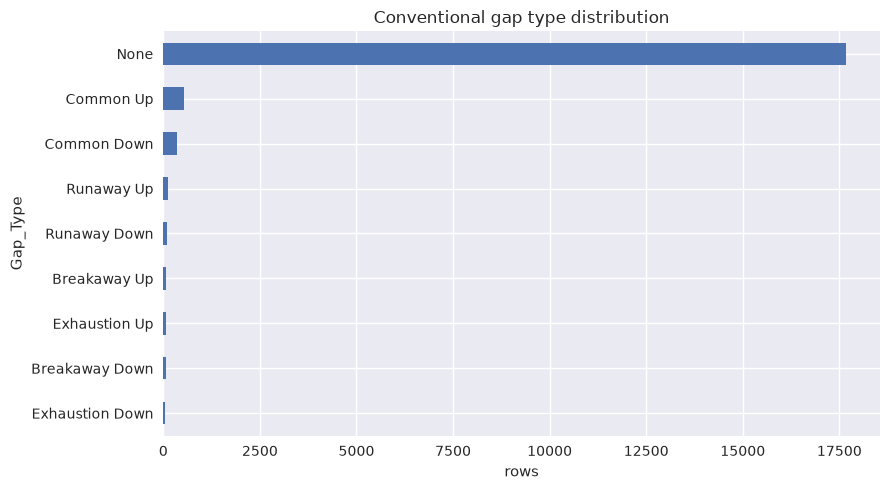

In [236]:
conventional_pd = conventional_gap_trading.to_pandas()
display(conventional_pd.head())

if "Gap_Type" in conventional_pd:
    gap_counts = conventional_pd["Gap_Type"].value_counts().sort_values(ascending=True)
    ax = gap_counts.plot.barh(figsize=(9, 5))
    ax.set_title("Conventional gap type distribution")
    ax.set_xlabel("rows")
    ax.set_ylabel("Gap_Type")
    plt.tight_layout()


## Visualize Gap Signals


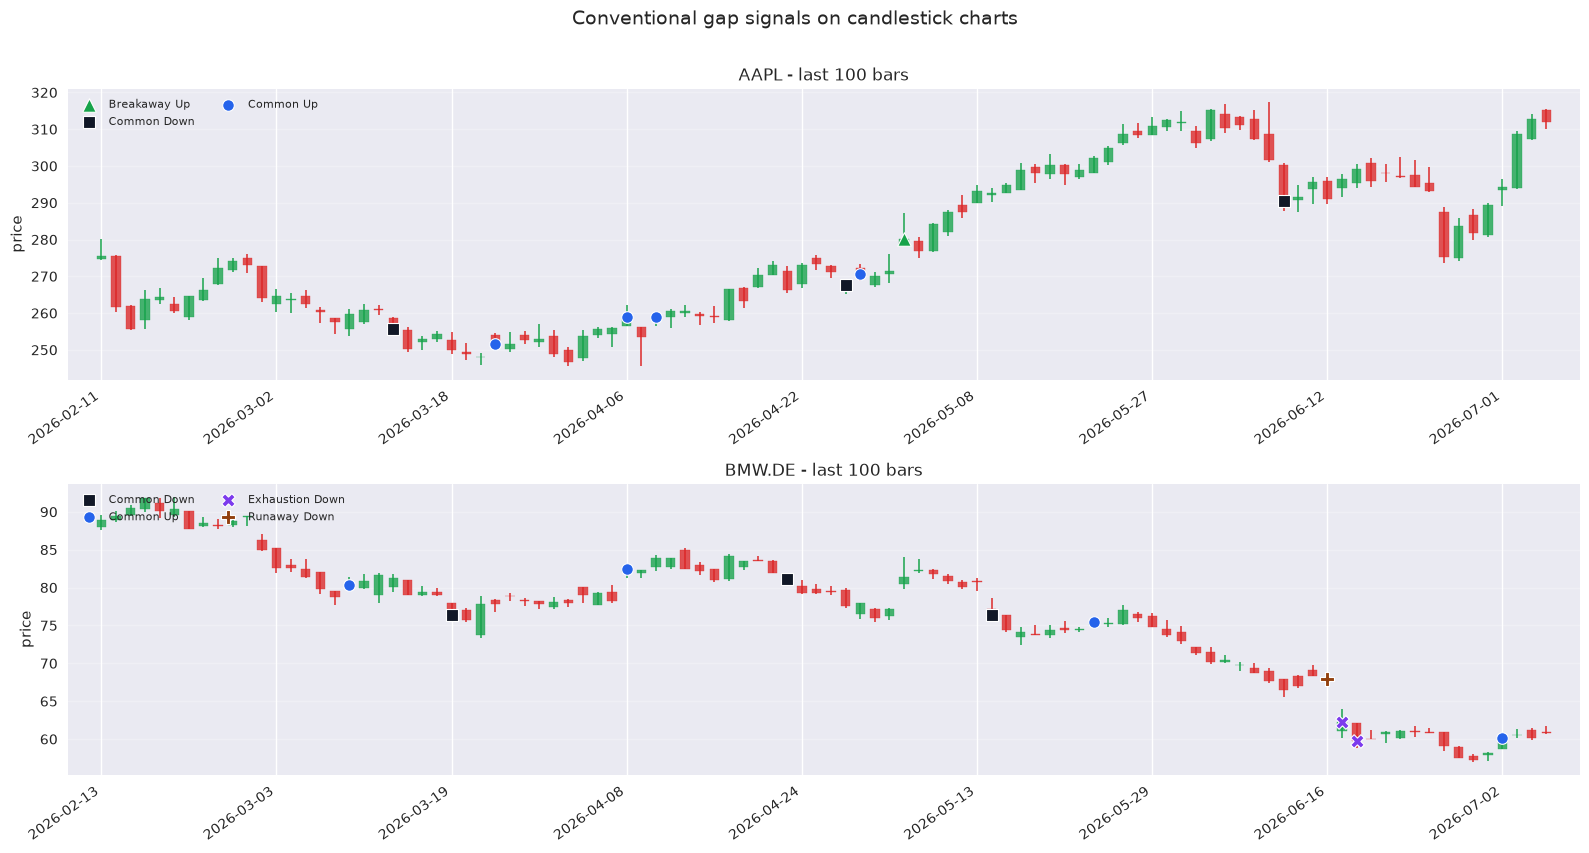

In [ ]:
plot_gap_signals_candlestick(conventional_pd, last_n=500)


## Publish Conventional Strategy Features


In [ ]:
conventional_gap_trading_publish_metadata = publish_conventional_gap_trading(
    conventional_gap_trading,
    conventional_gap_trading_metadata,
)
conventional_gap_trading_publish_metadata
